# 🏥 PharmaTrace AI — Warehouse & FEFO Inventory Optimization Dashboard
### Module 3 | ISB AMPBA Capstone | Sponsor: Innodatatics Inc.
---
**Analytics Modules Covered:**
1. Data Loading & Pharma Product Classification
2. Inventory Overview Dashboard
3. ABC-FSN Segmentation Matrix
4. FEFO Compliance Rate Analysis
5. Expiry Risk Heatmap (Days-to-Expiry Analysis)
6. 24-Month Demand Trend & Seasonality
7. Expiry Risk ML Classifier (Random Forest)
8. Inventory Cost Optimizer (Linear Programming)
9. Cold-Chain IoT Telemetry Monitoring
10. Executive KPI Summary Dashboard

## ⚙️ 1. Setup: Imports & Configuration

In [1]:
# Core libraries
import os
import warnings
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from IPython.display import display, HTML

# ML
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Optimisation
from scipy.optimize import linprog

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────
MASTER_PATH  = r'/Users/babitakironvedantam/Desktop/CAPSTONE FINAL/PharmaTrace AI - DATA/master_dataset/PharmaTrace_Master_Dataset.xlsx'
ADD_DATA_DIR = r'/Users/babitakironvedantam/Desktop/CAPSTONE FINAL/AI Modules/additional data'

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#ccc',
    'text.color':       '#eee',
    'xtick.color':      '#aaa',
    'ytick.color':      '#aaa',
    'grid.color':       '#2a2d3a',
    'grid.linestyle':   '--',
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})

PALETTE = ['#00d4ff', '#7c3aed', '#f59e0b', '#10b981', '#ef4444',
           '#3b82f6', '#ec4899', '#14b8a6', '#f97316', '#84cc16']

TODAY = pd.Timestamp('2026-08-23')
print('Setup complete. TODAY =', TODAY.date())

Setup complete. TODAY = 2026-08-23


## 📂 2. Data Loading & Pharma Product Classification

In [2]:
# ── Load master tables ────────────────────────────────────────────────────
products   = pd.read_excel(MASTER_PATH, sheet_name='products')
warehouses = pd.read_excel(MASTER_PATH, sheet_name='warehouses')
inventory  = pd.read_excel(MASTER_PATH, sheet_name='inventory')
batches    = pd.read_excel(MASTER_PATH, sheet_name='finished_product_batches')

# ── Merge batch manufacture date into inventory ────────────────────────────
inventory = inventory.merge(
    batches[['fp_batch_id', 'manufacture_date', 'qc_status', 'recall_flag']],
    on='fp_batch_id', how='left'
)

# ── Merge product info into inventory ─────────────────────────────────────
inventory = inventory.merge(
    products[['product_id', 'generic_name', 'brand_name', 'dosage_form',
               'route', 'pharm_class', 'dea_schedule', 'unit_price',
               'shelf_life_months', 'status']],
    on='product_id', how='left'
)

# ── Merge warehouse names ─────────────────────────────────────────────────
inventory = inventory.merge(
    warehouses[['warehouse_id', 'warehouse_name', 'state', 'temp_controlled', 'capacity_units']],
    on='warehouse_id', how='left'
)

# ── Date parsing ──────────────────────────────────────────────────────────
inventory['expiry_date']      = pd.to_datetime(inventory['expiry_date'],      errors='coerce')
inventory['manufacture_date'] = pd.to_datetime(inventory['manufacture_date'], errors='coerce')

# ── Derived columns ───────────────────────────────────────────────────────
inventory['days_to_expiry']      = (inventory['expiry_date'] - TODAY).dt.days
inventory['shelf_life_days']     = inventory['manufacture_date'].apply(
    lambda d: (inventory.loc[inventory['manufacture_date']==d, 'expiry_date'].values[0] - d).days
    if not pd.isna(d) else np.nan
)
# Simpler: (expiry - manufacture)
inventory['shelf_life_days'] = (inventory['expiry_date'] - inventory['manufacture_date']).dt.days
inventory['pct_life_remaining'] = (
    inventory['days_to_expiry'] / inventory['shelf_life_days'].replace(0, np.nan) * 100
).clip(0, 100)
inventory['inventory_value_usd'] = inventory['quantity_on_hand'] * inventory['unit_price']
inventory['is_cold_chain']        = inventory['dosage_form'].str.upper().str.contains(
    'INJECTION|SOLUTION|VACCINE', na=False
)
inventory['is_controlled']        = inventory['dea_schedule'].notna()

# ── Expiry risk bucket ────────────────────────────────────────────────────
def expiry_risk(d):
    if pd.isna(d): return 'Unknown'
    if d < 0:      return 'EXPIRED'
    if d <= 30:    return 'CRITICAL (<30d)'
    if d <= 90:    return 'HIGH (30-90d)'
    if d <= 180:   return 'MEDIUM (90-180d)'
    return 'LOW (>180d)'

inventory['expiry_risk'] = inventory['days_to_expiry'].apply(expiry_risk)

print(f'Inventory records : {len(inventory):,}')
print(f'Products loaded   : {inventory["product_id"].nunique():,}')
print(f'Warehouses        : {inventory["warehouse_id"].nunique()}')
print(f'Total stock value : USD {inventory["inventory_value_usd"].sum():,.0f}')
inventory[['product_id','generic_name','warehouse_id','quantity_on_hand',
            'days_to_expiry','expiry_risk','inventory_value_usd']].head()

Inventory records : 6,000
Products loaded   : 3,000
Warehouses        : 8
Total stock value : USD 2,086,867,745


,product_id,generic_name,warehouse_id,quantity_on_hand,days_to_expiry,expiry_risk,inventory_value_usd
0,PROD00001,metformin hydrochloride,WH002,100,-500,EXPIRED,3100.0
1,PROD00001,metformin hydrochloride,WH003,1640,123,MEDIUM (90-180d),50840.0
2,PROD00002,Ketorolac Tromethamine,WH004,1710,124,MEDIUM (90-180d),34200.0
3,PROD00002,Ketorolac Tromethamine,WH005,1780,125,MEDIUM (90-180d),35600.0
4,PROD00003,Vasopressin,WH006,1850,126,MEDIUM (90-180d),41625.0


In [3]:
# ── Load pharma-compliant supplementary datasets ─────────────────────────
df_demand  = pd.read_excel(os.path.join(ADD_DATA_DIR, '01_Pharma_Compliant_Monthly_Demand_24M.xlsx'))
df_txns    = pd.read_excel(os.path.join(ADD_DATA_DIR, '02_Pharma_Compliant_FEFO_Pick_Ledger.xlsx'))
df_econ    = pd.read_excel(os.path.join(ADD_DATA_DIR, '03_Pharma_Compliant_Unit_Economics_and_Costs.xlsx'))
df_freight = pd.read_excel(os.path.join(ADD_DATA_DIR, '04_Pharma_Compliant_Inter_Warehouse_Freight_Matrix.xlsx'))
df_iot     = pd.read_excel(os.path.join(ADD_DATA_DIR, '05_Pharma_Compliant_IoT_ColdChain_Telemetry_Logs.xlsx'))

# Parse timestamps
df_txns['timestamp'] = pd.to_datetime(df_txns['timestamp'], errors='coerce')
df_iot['timestamp']  = pd.to_datetime(df_iot['timestamp'],  errors='coerce')

print('Demand records    :', len(df_demand))
print('Transaction records:', len(df_txns))
print('Economics records :', len(df_econ))
print('Freight routes    :', len(df_freight))
print('IoT log records   :', len(df_iot))

Demand records    : 48000
Transaction records: 4000
Economics records : 3000
Freight routes    : 56
IoT log records   : 4800


## 📊 3. Inventory Overview Dashboard

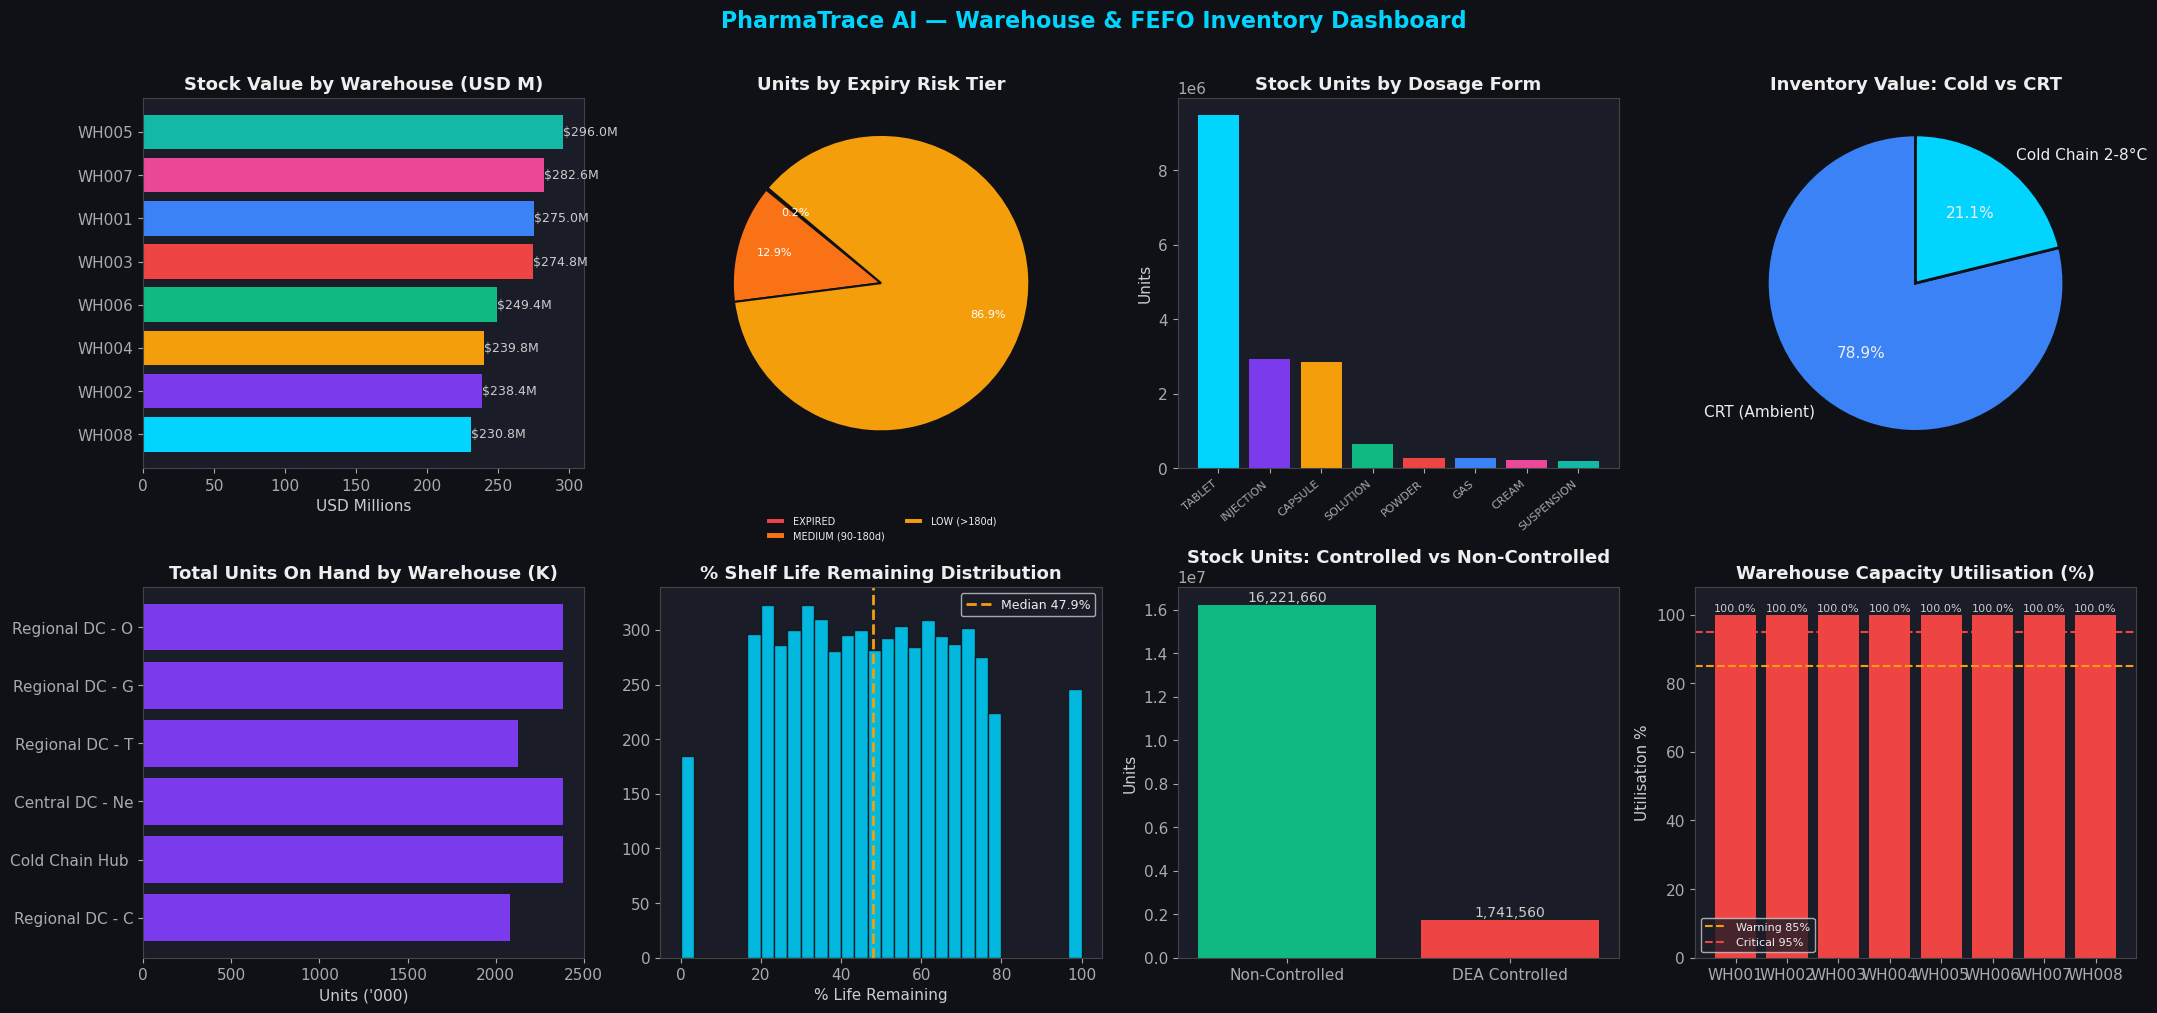

Dashboard Overview rendered.


In [4]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('PharmaTrace AI — Warehouse & FEFO Inventory Dashboard', fontsize=16, fontweight='bold', color='#00d4ff', y=1.04)
fig.text(0.5, 1.005, 'High-level snapshot of pharmaceutical inventory across 8 warehouses -- stock value, expiry risk, capacity usage',
         ha='center', va='top', fontsize=9, color='#aaaaaa', style='italic')
fig.text(0.5, 0.985, 'WH=Warehouse  |  SKU=Stock Keeping Unit  |  DTE=Days-to-Expiry  |  CRT=Controlled Room Temperature (15-30 deg C)  |  DEA=Drug Enforcement Administration',
         ha='center', va='top', fontsize=8, color='#888888', style='italic')

# ── Panel 1: Stock Value by Warehouse ──────────────────────────────────────
ax = axes[0, 0]
wh_val = inventory.groupby('warehouse_id')['inventory_value_usd'].sum().sort_values(ascending=True)
bars = ax.barh(wh_val.index, wh_val.values / 1e6, color=PALETTE[:len(wh_val)])
ax.set_title('Stock Value by Warehouse\n(USD M = US Dollars Millions held per warehouse)')
ax.set_xlabel('USD Millions')
for bar, v in zip(bars, wh_val.values):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'${v/1e6:.1f}M', va='center', fontsize=9, color='#ccc')

# ── Panel 2: Expiry Risk Distribution ──────────────────────────────────────
ax = axes[0, 1]
risk_order = ['EXPIRED', 'CRITICAL (<30d)', 'HIGH (30-90d)', 'MEDIUM (90-180d)', 'LOW (>180d)']
risk_counts = inventory.groupby('expiry_risk')['quantity_on_hand'].sum().reindex(
    [r for r in risk_order if r in inventory['expiry_risk'].unique()], fill_value=0
)
risk_colors = ['#ef4444', '#f97316', '#f59e0b', '#3b82f6', '#10b981']
wedges, texts, autotexts = ax.pie(
    risk_counts.values, labels=None,
    autopct='%1.1f%%', colors=risk_colors[:len(risk_counts)],
    startangle=140, pctdistance=0.75,
    wedgeprops={'edgecolor': '#0f1117', 'linewidth': 1.5}
)
for at in autotexts: at.set_fontsize(8); at.set_color('white')
ax.set_title('Units by Expiry Risk Tier\n(DTE thresholds: <0d=EXPIRED | <30d=CRITICAL | 30-90d=HIGH | 90-180d=MEDIUM | >180d=LOW)')
ax.legend(risk_counts.index, loc='lower center', fontsize=7, ncol=2,
          bbox_to_anchor=(0.5, -0.22), framealpha=0)

# ── Panel 3: Units by Dosage Form ──────────────────────────────────────────
ax = axes[0, 2]
# simplify dosage names
inventory['dosage_short'] = inventory['dosage_form'].str.split(',').str[0].str.strip().str[:20]
top_dosage = inventory.groupby('dosage_short')['quantity_on_hand'].sum().nlargest(8)
ax.bar(range(len(top_dosage)), top_dosage.values, color=PALETTE[:len(top_dosage)])
ax.set_xticks(range(len(top_dosage)))
ax.set_xticklabels(top_dosage.index, rotation=40, ha='right', fontsize=8)
ax.set_title('Stock Units by Dosage Form\n(Top 8 product forms: Tablet | Capsule | Injection | Solution | etc.)')
ax.set_ylabel('Units')

# ── Panel 4: Cold-Chain vs CRT Split ───────────────────────────────────────
ax = axes[0, 3]
cc_split = inventory.groupby('is_cold_chain')['inventory_value_usd'].sum()
labels = ['CRT (Ambient)', 'Cold Chain 2-8°C']
ax.pie(cc_split.values, labels=labels, autopct='%1.1f%%',
       colors=['#3b82f6', '#00d4ff'], startangle=90,
       wedgeprops={'edgecolor': '#0f1117', 'linewidth': 2})
ax.set_title('Inventory Value: Cold Chain (2-8 deg C) vs CRT\n(CRT = Controlled Room Temperature, 15-30 deg C per USP<659>)')

# ── Panel 5: QTY on Hand by Warehouse (box plot proxy = bar by WH) ─────────
ax = axes[1, 0]
wh_qty = inventory.groupby('warehouse_name')['quantity_on_hand'].sum().sort_values(ascending=True)
ax.barh(wh_qty.index.str[:15], wh_qty.values / 1000, color='#7c3aed')
ax.set_title('Total Units On Hand by Warehouse\n(K = Thousands of physical stock units per warehouse)')
ax.set_xlabel("Units ('000) -- quantity_on_hand summed per warehouse")

# ── Panel 6: % Life Remaining Distribution ─────────────────────────────────
ax = axes[1, 1]
pct_vals = inventory['pct_life_remaining'].dropna()
ax.hist(pct_vals, bins=30, color='#00d4ff', edgecolor='#0f1117', alpha=0.85)
ax.axvline(pct_vals.median(), color='#f59e0b', linestyle='--', lw=2, label=f'Median {pct_vals.median():.1f}%')
ax.set_title('% Shelf Life Remaining Distribution\n(pct_life_remaining = days_to_expiry / shelf_life_days x 100)')
ax.set_xlabel('% Life Remaining (100% = newly manufactured | 0% = at expiry date)')
ax.legend(fontsize=9)

# ── Panel 7: Controlled vs Non-Controlled Stock ────────────────────────────
ax = axes[1, 2]
ctrl = inventory.groupby('is_controlled')['quantity_on_hand'].sum()
ax.bar(['Non-Controlled', 'DEA Controlled'], ctrl.values, color=['#10b981', '#ef4444'])
ax.set_title('Stock Units: DEA Controlled vs Non-Controlled\n(DEA = Drug Enforcement Administration | Controlled = scheduled narcotic / regulated drug)')
ax.set_ylabel('Units')
for i, v in enumerate(ctrl.values):
    ax.text(i, v + max(ctrl.values)*0.01, f'{v:,.0f}', ha='center', fontsize=10, color='#ccc')

# ── Panel 8: Warehouse Capacity Utilisation ────────────────────────────────
ax = axes[1, 3]
wh_units = inventory.groupby('warehouse_id')['quantity_on_hand'].sum().reset_index()
wh_units = wh_units.merge(warehouses[['warehouse_id','capacity_units']], on='warehouse_id', how='left')
wh_units['utilisation_pct'] = (wh_units['quantity_on_hand'] / wh_units['capacity_units'] * 100).clip(0, 100)
util_colors = ['#ef4444' if u > 90 else '#f59e0b' if u > 75 else '#10b981' for u in wh_units['utilisation_pct']]
ax.bar(wh_units['warehouse_id'], wh_units['utilisation_pct'], color=util_colors)
ax.axhline(85, color='#f59e0b', linestyle='--', lw=1.5, label='Warning 85%')
ax.axhline(95, color='#ef4444', linestyle='--', lw=1.5, label='Critical 95%')
ax.set_title('Warehouse Capacity Utilisation (%)\n(utilisation = units_on_hand / capacity_units x 100 | Warning >= 85% | Critical >= 95%)')
ax.set_ylabel('Utilisation % -- % of total storage capacity currently occupied')
ax.set_ylim(0, 108)
ax.legend(fontsize=8)
for i, (_, rw) in enumerate(wh_units.iterrows()):
    ax.text(i, rw['utilisation_pct'] + 1, f"{rw['utilisation_pct']:.1f}%", ha='center', fontsize=8, color='#ccc')

plt.tight_layout()
plt.savefig('dashboard_overview.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Dashboard Overview rendered.')

## 🔶 4. ABC-FSN Inventory Segmentation

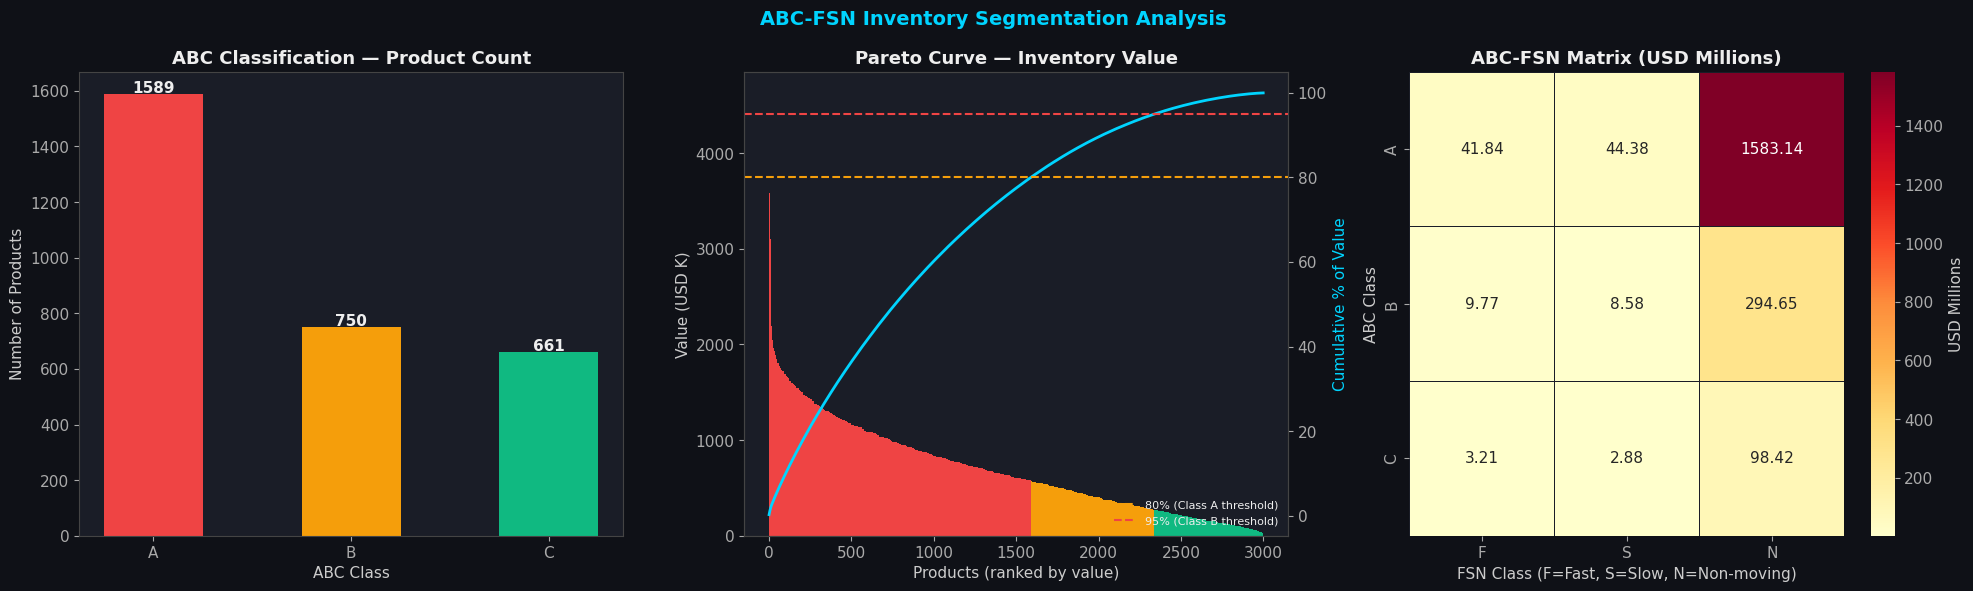

ABC-FSN segment breakdown:


,Products,Total_Value_USD,Avg_Monthly_Dispatch
segment,,,
AN,1504,1.583135e+09,29.68
BN,706,2.946463e+08,33.72
CN,623,9.842382e+07,30.77
AS,46,4.438072e+07,62.53
AF,39,4.184002e+07,103.70
BF,24,9.773975e+06,116.09
BS,20,8.579225e+06,62.73
CF,22,3.205595e+06,112.47
CS,16,2.883025e+06,61.85


In [5]:
# ── ABC by Value (Pareto) ──────────────────────────────────────────────────
prod_val = (
    inventory.groupby('product_id')
    .agg(total_value=('inventory_value_usd', 'sum'),
         total_units=('quantity_on_hand', 'sum'))
    .sort_values('total_value', ascending=False)
    .reset_index()
)
prod_val['cum_pct'] = prod_val['total_value'].cumsum() / prod_val['total_value'].sum() * 100
prod_val['abc'] = 'C'
prod_val.loc[prod_val['cum_pct'] <= 80, 'abc'] = 'A'
prod_val.loc[(prod_val['cum_pct'] > 80) & (prod_val['cum_pct'] <= 95), 'abc'] = 'B'

# ── FSN by Demand Velocity ─────────────────────────────────────────────────
velocity = (
    df_demand.groupby('product_id')['quantity_dispatched_units']
    .mean()
    .reset_index()
    .rename(columns={'quantity_dispatched_units': 'avg_monthly_dispatch'})
)
v_q33, v_q66 = velocity['avg_monthly_dispatch'].quantile([0.33, 0.66])
velocity['fsn'] = velocity['avg_monthly_dispatch'].apply(
    lambda v: 'F' if v >= v_q66 else ('S' if v >= v_q33 else 'N')
)

# ── Merge ABC + FSN ────────────────────────────────────────────────────────
abc_fsn = prod_val.merge(velocity, on='product_id', how='left')
abc_fsn['fsn'] = abc_fsn['fsn'].fillna('N')
abc_fsn['segment'] = abc_fsn['abc'] + abc_fsn['fsn']

# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('ABC-FSN Inventory Segmentation Analysis', fontsize=14, color='#00d4ff', fontweight='bold', y=1.04)
fig.text(0.5, 1.01, 'Ranks every product by TWO independent criteria to pinpoint which SKUs need the most urgent attention',
         ha='center', va='top', fontsize=9, color='#aaaaaa', style='italic')
fig.text(0.5, 0.985, 'ABC = Activity-Based Classification (A=top 80% value | B=next 15% | C=bottom 5%)  |  FSN = Fast/Slow/Non-moving (by avg monthly dispatch velocity)',
         ha='center', va='top', fontsize=8, color='#888888', style='italic')

# Panel A: ABC Distribution
ax = axes[0]
abc_counts = abc_fsn['abc'].value_counts().reindex(['A', 'B', 'C'])
abc_colors = {'A': '#ef4444', 'B': '#f59e0b', 'C': '#10b981'}
bars = ax.bar(abc_counts.index, abc_counts.values,
              color=[abc_colors[k] for k in abc_counts.index], width=0.5)
ax.set_title('ABC Classification -- Product Count\n(A=High-Value Top-80% | B=Mid 15% | C=Low-Value Bottom 5%)')
ax.set_xlabel('ABC Class (ranked by cumulative inventory value -- Pareto / 80-20 rule)')
ax.set_ylabel('Number of unique Products (SKUs) in each class')
for bar, v in zip(bars, abc_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(v), ha='center', fontweight='bold', color='#eee')

# Panel B: Pareto Curve
ax = axes[1]
x = range(len(prod_val))
color_vals = ['#ef4444' if r == 'A' else '#f59e0b' if r == 'B' else '#10b981'
              for r in prod_val['abc']]
ax.bar(x, prod_val['total_value'] / 1e3, color=color_vals, width=1.0)
ax2 = ax.twinx()
ax2.plot(x, prod_val['cum_pct'], color='#00d4ff', lw=2)
ax2.axhline(80, color='#f59e0b', linestyle='--', lw=1.5, label='80% (Class A threshold)')
ax2.axhline(95, color='#ef4444', linestyle='--', lw=1.5, label='95% (Class B threshold)')
ax2.set_ylabel('Cumulative % of Value', color='#00d4ff')
ax2.legend(loc='lower right', fontsize=8, framealpha=0)
ax.set_title('Pareto Curve -- Inventory Value\n(Pareto/80-20: ~20% of SKUs hold ~80% of total stock value)')
ax.set_xlabel('Products ranked highest-to-lowest by inventory value (USD)')
ax.set_ylabel('Value (USD K = US Dollars Thousands)')

# Panel C: ABC-FSN Heatmap
ax = axes[2]
pivot = abc_fsn.groupby(['abc', 'fsn'])['total_value'].sum().unstack(fill_value=0) / 1e6
pivot = pivot.reindex(index=['A', 'B', 'C'], columns=['F', 'S', 'N'], fill_value=0)
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=ax, cbar_kws={'label': 'USD Millions'},
            linewidths=0.5, linecolor='#1a1d27')
ax.set_title('ABC-FSN Cross-Matrix (USD Millions)\nCritical quadrant: A-N = High-value + Non-moving => highest financial risk')
ax.set_xlabel('FSN Class: F=Fast-moving (frequent dispatch) | S=Slow | N=Non-moving (no recent dispatch)')
ax.set_ylabel('ABC Class: A=High-value | B=Medium-value | C=Low-value')

plt.tight_layout()
plt.savefig('abc_fsn_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print('ABC-FSN segment breakdown:')
seg_summary = abc_fsn.groupby('segment').agg(
    Products=('product_id','count'),
    Total_Value_USD=('total_value','sum'),
    Avg_Monthly_Dispatch=('avg_monthly_dispatch','mean')
).round(2)
display(seg_summary.sort_values('Total_Value_USD', ascending=False))

## ✅ 5. FEFO Compliance Rate Analysis

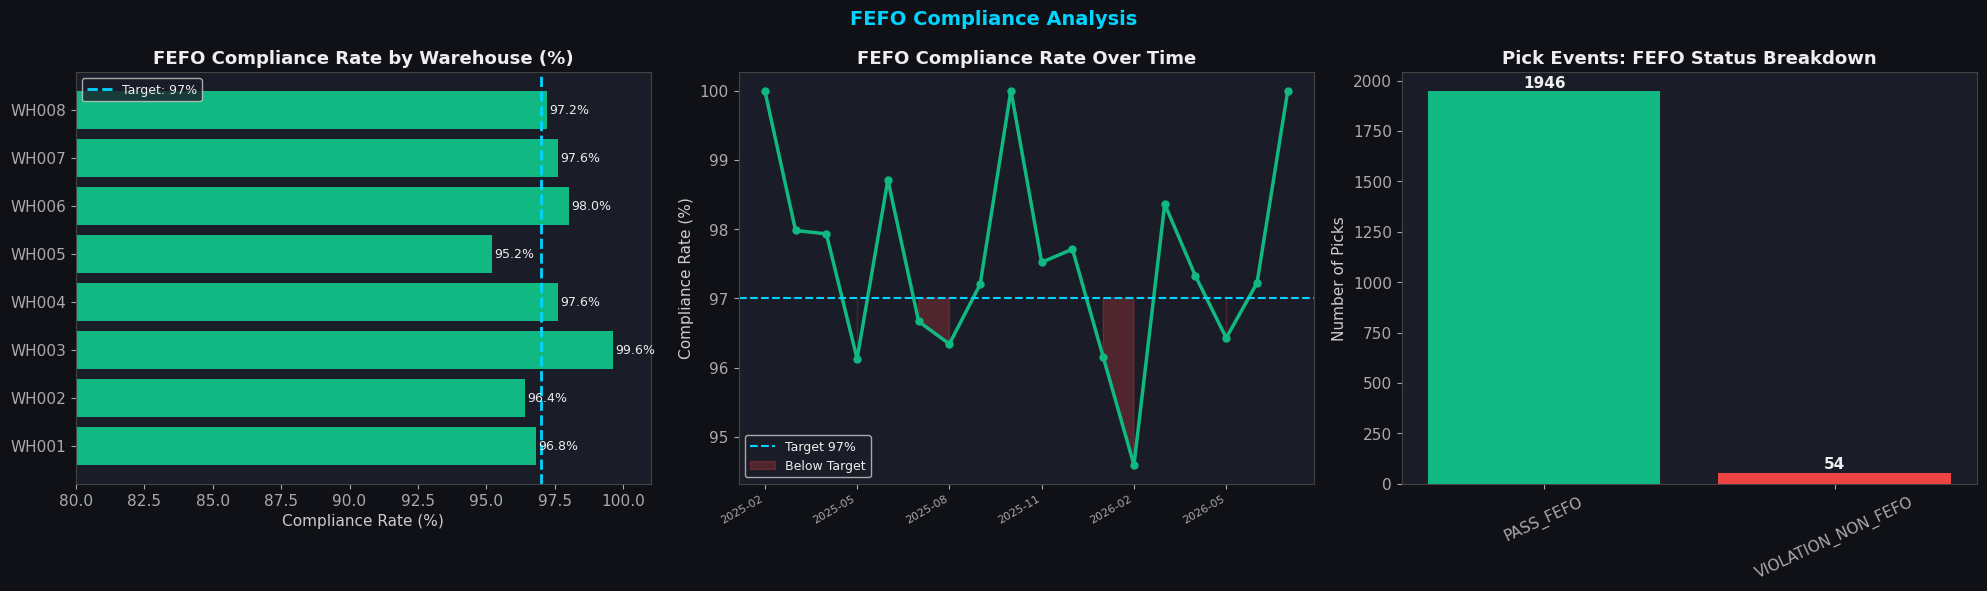

Overall FEFO Compliance Rate: 97.30%


,total_picks,fefo_picks,compliance_rate_pct
warehouse_id,,,
WH001,250,242,96.8
WH002,250,241,96.4
WH003,250,249,99.6
WH004,250,244,97.6
WH005,250,238,95.2
WH006,250,245,98.0
WH007,250,244,97.6
WH008,250,243,97.2


In [6]:
# ── Compliance rate by warehouse and by month ─────────────────────────────
picks = df_txns[df_txns['transaction_type'] == 'OUTBOUND_DISPATCH_PICK'].copy()
picks['month'] = picks['timestamp'].dt.to_period('M').astype(str)

fefo_wh = picks.groupby('warehouse_id').agg(
    total_picks=('transaction_id', 'count'),
    fefo_picks=('is_fefo_compliant', 'sum')
).reset_index()
fefo_wh['compliance_rate_pct'] = fefo_wh['fefo_picks'] / fefo_wh['total_picks'] * 100

fefo_monthly = picks.groupby('month').agg(
    total_picks=('transaction_id', 'count'),
    fefo_picks=('is_fefo_compliant', 'sum')
).reset_index()
fefo_monthly['compliance_rate_pct'] = fefo_monthly['fefo_picks'] / fefo_monthly['total_picks'] * 100
fefo_monthly = fefo_monthly.sort_values('month')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('FEFO Compliance Rate Analysis', fontsize=14, color='#00d4ff', fontweight='bold', y=1.04)
fig.text(0.5, 1.01, 'FEFO = First Expiry, First Out -- measures how consistently pickers dispatch the soonest-to-expire batch first to minimise waste',
         ha='center', va='top', fontsize=9, color='#aaaaaa', style='italic')
fig.text(0.5, 0.985, 'FEFO Violation = newer batch picked while an older batch of the same product was still in stock | Target: >= 97% | WMS = Warehouse Management System',
         ha='center', va='top', fontsize=8, color='#888888', style='italic')

# Panel A: Compliance by Warehouse
ax = axes[0]
colors = ['#10b981' if r >= 95 else '#f59e0b' if r >= 85 else '#ef4444'
          for r in fefo_wh['compliance_rate_pct']]
bars = ax.barh(fefo_wh['warehouse_id'], fefo_wh['compliance_rate_pct'], color=colors)
ax.axvline(97, color='#00d4ff', linestyle='--', lw=2, label='Target: 97%')
ax.set_xlim(80, 101)
ax.set_title('FEFO Compliance Rate by Warehouse (%)\n(% of picks that correctly dispatched the earliest-expiry batch first)')
ax.set_xlabel('Compliance Rate (%) -- Target >= 97% per FDA / DSCSA guidelines')
for bar, v in zip(bars, fefo_wh['compliance_rate_pct']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{v:.1f}%', va='center', fontsize=9)
ax.legend(fontsize=9)

# Panel B: Monthly trend
ax = axes[1]
months_list = fefo_monthly['month'].tolist()
x_pos = range(len(months_list))
ax.plot(x_pos, fefo_monthly['compliance_rate_pct'], color='#10b981', lw=2.5, marker='o', markersize=5)
ax.axhline(97, color='#00d4ff', linestyle='--', lw=1.5, label='Target 97%')
ax.fill_between(x_pos, fefo_monthly['compliance_rate_pct'], 97,
                where=[v < 97 for v in fefo_monthly['compliance_rate_pct']],
                color='#ef4444', alpha=0.25, label='Below Target')
ax.set_xticks(list(x_pos)[::max(1, len(months_list)//6)])
ax.set_xticklabels(months_list[::max(1, len(months_list)//6)], rotation=30, ha='right', fontsize=8)
ax.set_title('FEFO Compliance Rate Over Time\n(Monthly trend -- red shading = months below the 97% regulatory target)')
ax.set_ylabel('Compliance Rate (%) -- 100% = every pick event was FEFO-compliant')
ax.legend(fontsize=9)

# Panel C: FEFO vs Non-FEFO pick volume
ax = axes[2]
fc_counts = picks['compliance_status'].value_counts()
fc_colors = ['#10b981' if 'PASS' in s else '#ef4444' for s in fc_counts.index]
ax.bar(fc_counts.index, fc_counts.values, color=fc_colors)
ax.set_title('Pick Events: FEFO Status Breakdown\n(PASS_FEFO = correct pick | VIOLATION_NON_FEFO = older batch was available but skipped)')
ax.set_ylabel('Number of Pick Events (outbound dispatch picks recorded in ledger)')
ax.tick_params(axis='x', rotation=25)
for i, (idx, v) in enumerate(fc_counts.items()):
    ax.text(i, v + max(fc_counts)*0.01, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('fefo_compliance.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

overall_rate = picks['is_fefo_compliant'].mean() * 100
print(f'Overall FEFO Compliance Rate: {overall_rate:.2f}%')
display(fefo_wh.set_index('warehouse_id')[['total_picks','fefo_picks','compliance_rate_pct']].round(2))

## 🌡️ 6. Expiry Risk Heatmap (Days-to-Expiry Analysis)

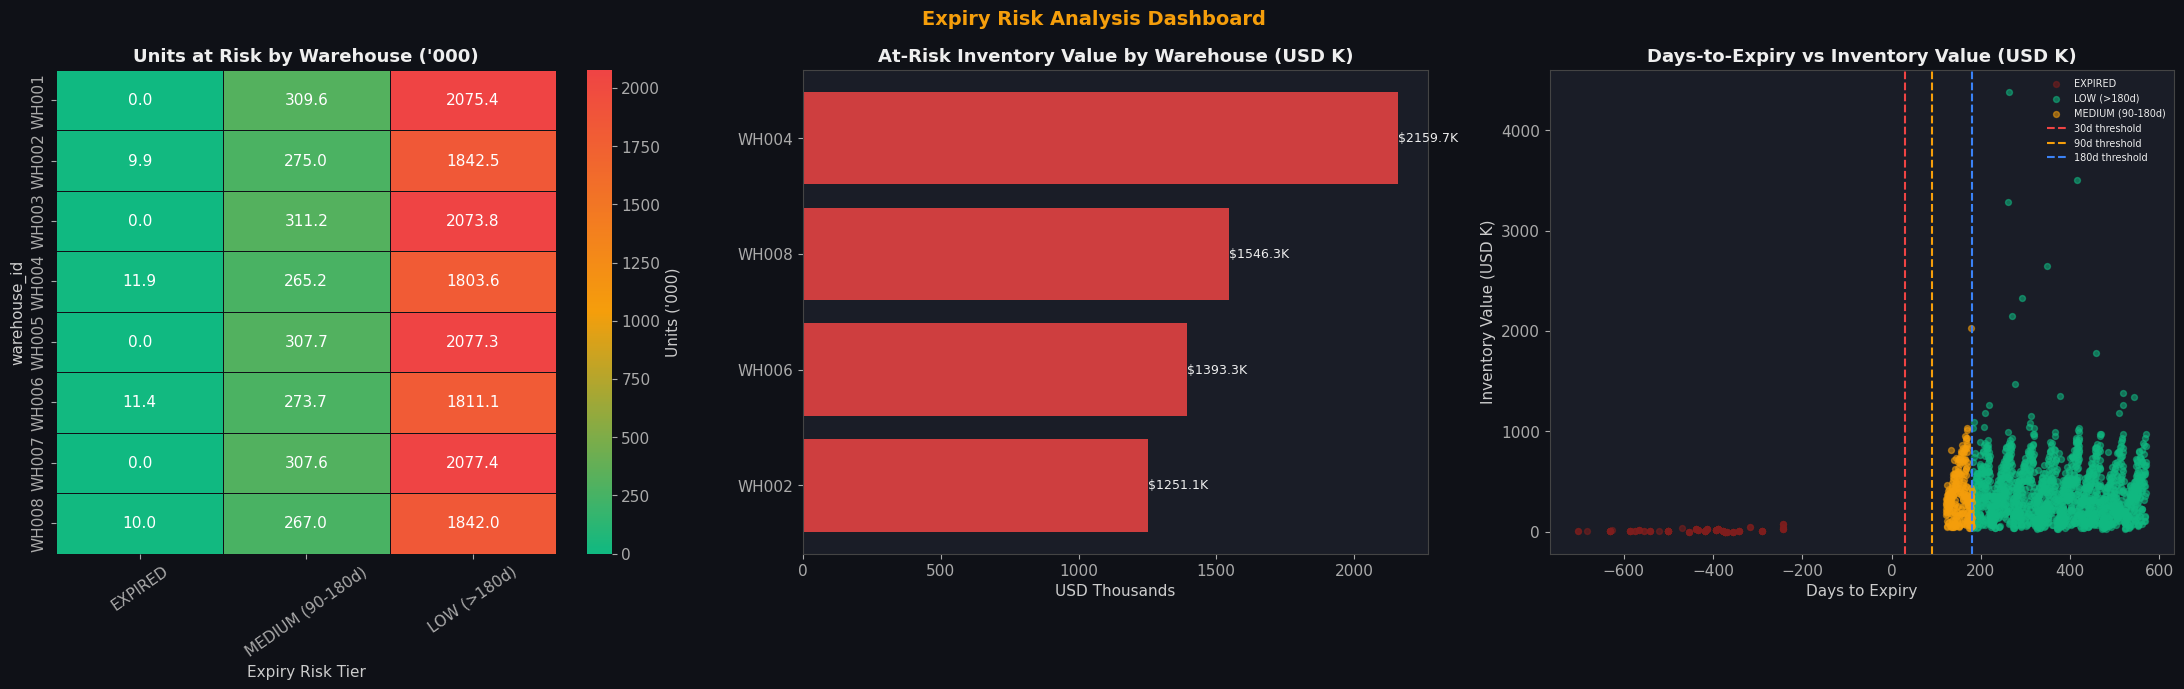

Expired & At-Risk Stock Summary:


,Products,Total_Units,Total_Value_USD
expiry_risk,,,
EXPIRED,432,43200,6.350400e+06
MEDIUM (90-180d),432,2316960,2.650862e+08
LOW (>180d),2592,15603060,1.815431e+09


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Expiry Risk Heatmap -- Days-to-Expiry (DTE) Analysis', fontsize=14, color='#f59e0b', fontweight='bold', y=1.04)
fig.text(0.5, 1.01, 'DTE = Days-to-Expiry: how many days remain before a batch crosses its expiry date. Lower DTE = higher urgency to dispatch or liquidate.',
         ha='center', va='top', fontsize=9, color='#aaaaaa', style='italic')
fig.text(0.5, 0.985, 'Risk Tiers: EXPIRED(<0d) | CRITICAL(<30d) | HIGH(30-90d) | MEDIUM(90-180d) | LOW(>180d)  |  Financial exposure escalates as DTE shrinks',
         ha='center', va='top', fontsize=8, color='#888888', style='italic')

# ── Panel A: Risk Heatmap (Warehouse x Risk Tier) ──────────────────────────
ax = axes[0]
pivot_risk = inventory.pivot_table(
    values='quantity_on_hand', index='warehouse_id',
    columns='expiry_risk', aggfunc='sum', fill_value=0
)
col_order = [c for c in ['EXPIRED','CRITICAL (<30d)','HIGH (30-90d)','MEDIUM (90-180d)','LOW (>180d)'] if c in pivot_risk.columns]
pivot_risk = pivot_risk[col_order]
cmap_risk = LinearSegmentedColormap.from_list('risk', ['#10b981', '#f59e0b', '#ef4444'])
sns.heatmap(pivot_risk / 1000, annot=True, fmt='.1f', cmap=cmap_risk,
            ax=ax, cbar_kws={'label': "Units ('000)"},
            linewidths=0.5, linecolor='#0f1117')
ax.set_title("Units at Risk by Warehouse ('000)\n(Heatmap: brighter/redder cells = more units in that risk tier at that warehouse)")
ax.set_xlabel('Expiry Risk Tier (DTE = Days-to-Expiry; columns ordered from most urgent EXPIRED to LOW risk)')
ax.tick_params(axis='x', rotation=35)

# ── Panel B: At-Risk Value by Warehouse ────────────────────────────────────
ax = axes[1]
at_risk = inventory[inventory['expiry_risk'].isin(['EXPIRED','CRITICAL (<30d)','HIGH (30-90d)'])]
risk_val = at_risk.groupby('warehouse_id')['inventory_value_usd'].sum().sort_values(ascending=True)
ax.barh(risk_val.index, risk_val.values / 1e3, color='#ef4444', alpha=0.85)
ax.set_title('At-Risk Inventory Value by Warehouse (USD K)\n(At-Risk = EXPIRED + CRITICAL(<30d) + HIGH(30-90d) combined inventory value)')
ax.set_xlabel('USD K = US Dollars Thousands (financial exposure of near-expiry stock)')
for bar, v in zip(ax.patches, risk_val.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'${v/1e3:.1f}K', va='center', fontsize=9)

# ── Panel C: DTE Scatter (Value vs DTE) ───────────────────────────────────
ax = axes[2]
risk_palette = {'EXPIRED':'#7f1d1d','CRITICAL (<30d)':'#ef4444','HIGH (30-90d)':'#f97316',
                'MEDIUM (90-180d)':'#f59e0b','LOW (>180d)':'#10b981','Unknown':'#6b7280'}
sample = inventory.dropna(subset=['days_to_expiry']).sample(min(2000, len(inventory)), random_state=42)
for risk_cat, grp in sample.groupby('expiry_risk'):
    ax.scatter(grp['days_to_expiry'], grp['inventory_value_usd'] / 1e3,
               label=risk_cat, alpha=0.55, s=18,
               color=risk_palette.get(risk_cat, '#888'))
ax.axvline(30,  color='#ef4444', linestyle='--', lw=1.5, label='30d threshold')
ax.axvline(90,  color='#f59e0b', linestyle='--', lw=1.5, label='90d threshold')
ax.axvline(180, color='#3b82f6', linestyle='--', lw=1.5, label='180d threshold')
ax.set_title('DTE vs Inventory Value Scatter\n(Each dot = 1 batch | left=near-expiry/high-urgency | right=ample shelf life remaining)')
ax.set_xlabel('DTE -- Days to Expiry (dashed lines mark 30d, 90d, 180d risk thresholds)')
ax.set_ylabel('Inventory Value (USD K = Thousands) -- dot height shows financial stake')
ax.legend(fontsize=7, framealpha=0)

plt.tight_layout()
plt.savefig('expiry_risk_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print('Expired & At-Risk Stock Summary:')
display(
    inventory.groupby('expiry_risk').agg(
        Products=('product_id','nunique'),
        Total_Units=('quantity_on_hand','sum'),
        Total_Value_USD=('inventory_value_usd','sum')
    ).reindex([r for r in ['EXPIRED','CRITICAL (<30d)','HIGH (30-90d)','MEDIUM (90-180d)','LOW (>180d)','Unknown']
               if r in inventory['expiry_risk'].unique()]).round(2)
)

## 📈 7. 24-Month Demand Trend & Seasonality

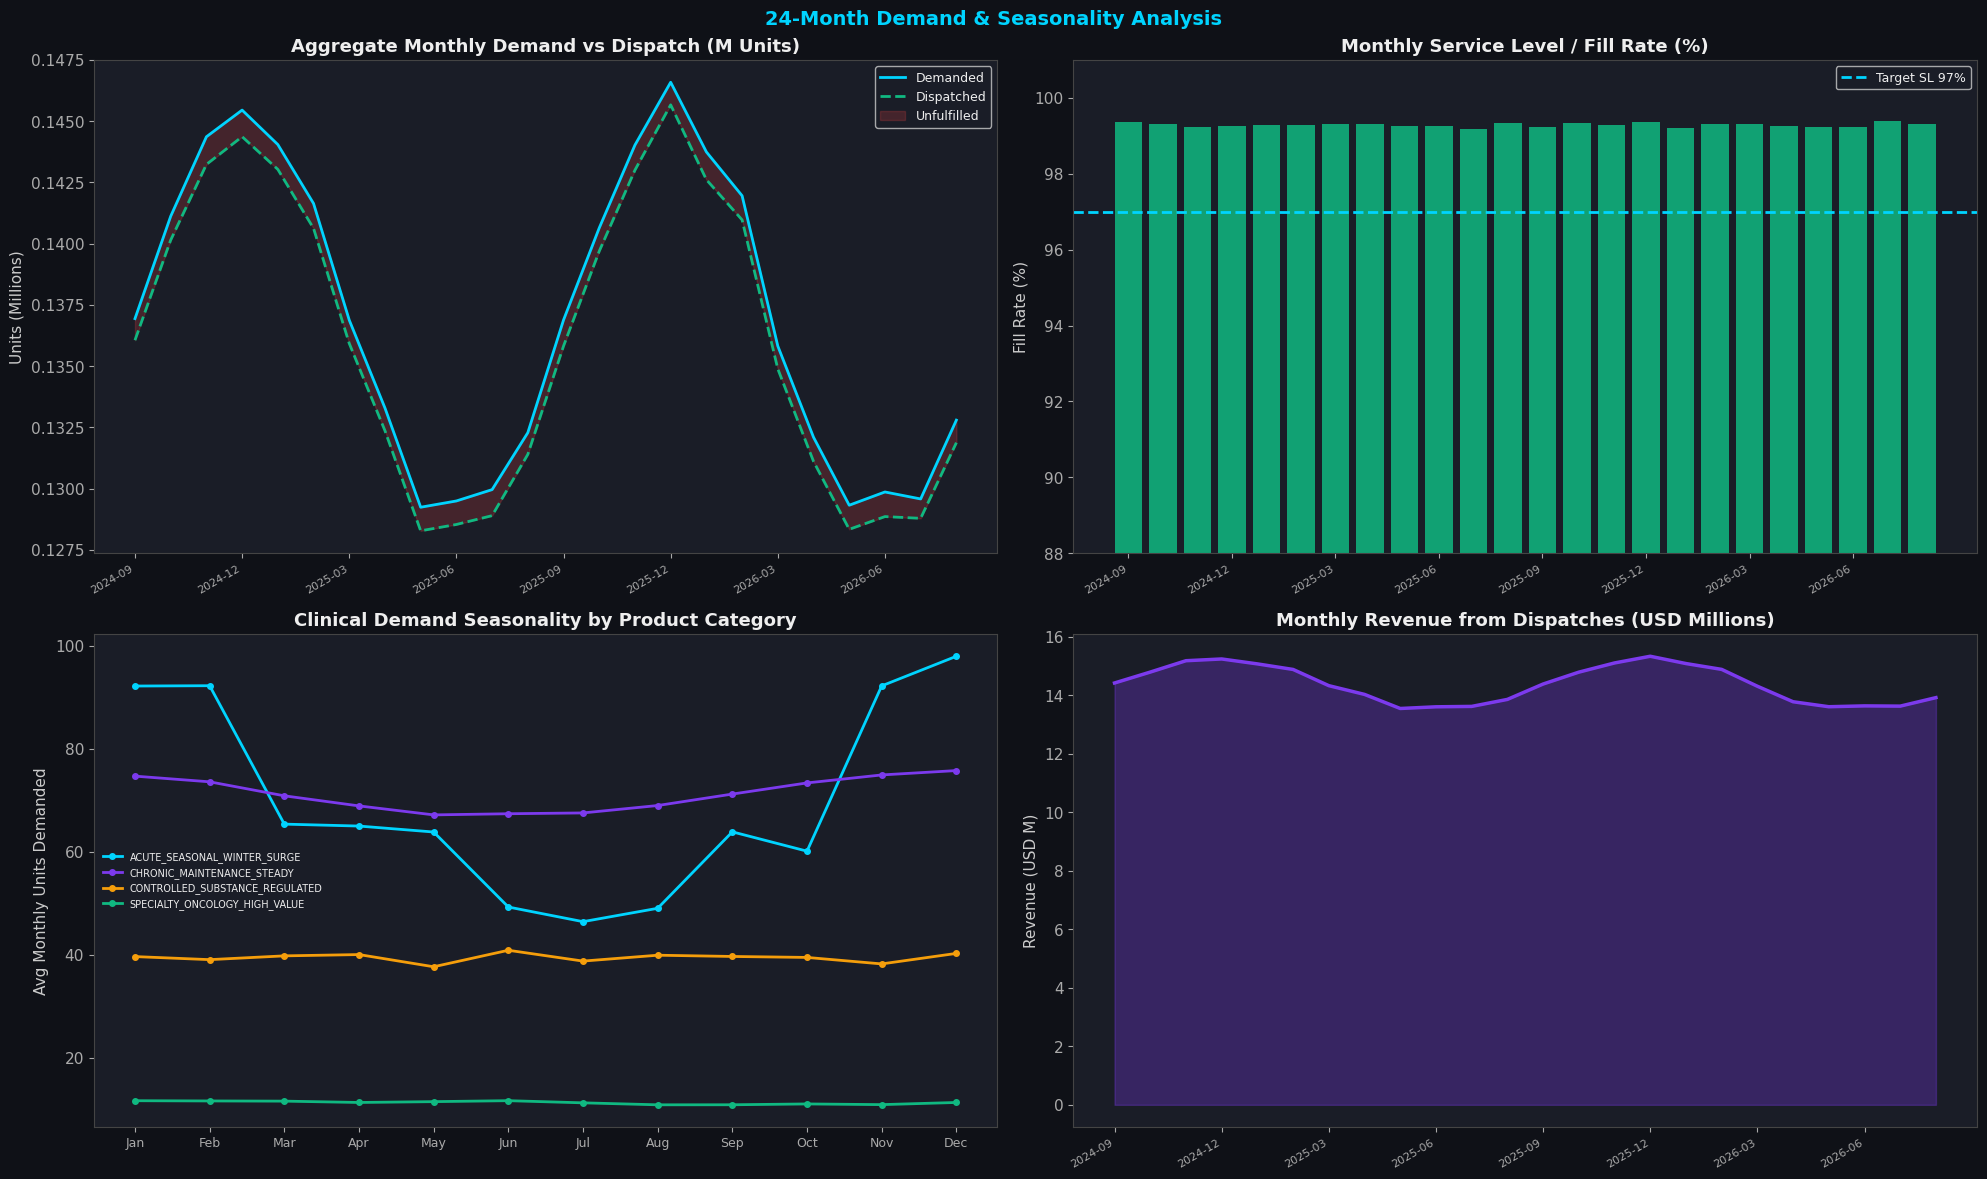

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('24-Month Demand Trend & Seasonality Analysis', fontsize=14, color='#00d4ff', fontweight='bold', y=1.03)
fig.text(0.5, 1.005, 'Analyses 24 months of dispatch history to reveal demand trends, seasonal spikes, and service-level performance across the network',
         ha='center', va='top', fontsize=9, color='#aaaaaa', style='italic')
fig.text(0.5, 0.985, 'SL=Service Level (Fill Rate) | Demanded=units ordered | Dispatched=units shipped | Unfulfilled=demand gap | M=Millions',
         ha='center', va='top', fontsize=8, color='#888888', style='italic')

# ── A: Aggregate Monthly Demand ──────────────────────────────────────────
ax = axes[0, 0]
monthly_agg = df_demand.groupby('year_month').agg(
    demanded=('quantity_demanded_units','sum'),
    dispatched=('quantity_dispatched_units','sum')
).reset_index().sort_values('year_month')
x = range(len(monthly_agg))
ax.plot(x, monthly_agg['demanded']   / 1e6, label='Demanded',   color='#00d4ff', lw=2)
ax.plot(x, monthly_agg['dispatched'] / 1e6, label='Dispatched', color='#10b981', lw=2, linestyle='--')
ax.fill_between(x, monthly_agg['demanded']/1e6, monthly_agg['dispatched']/1e6,
                alpha=0.2, color='#ef4444', label='Unfulfilled')
step = max(1, len(monthly_agg)//8)
ax.set_xticks(list(x)[::step])
ax.set_xticklabels(monthly_agg['year_month'].tolist()[::step], rotation=30, ha='right', fontsize=8)
ax.set_title('Aggregate Monthly Demand vs Dispatch (M Units)\n(Demanded=orders received | Dispatched=fulfilled | Red gap=unfulfilled demand)')
ax.set_ylabel('Units (M = Millions of physical stock units ordered / shipped)')
ax.legend(fontsize=9)

# ── B: Service Level (Fill Rate) by Month ────────────────────────────────
ax = axes[0, 1]
monthly_agg['fill_rate'] = monthly_agg['dispatched'] / monthly_agg['demanded'] * 100
colors_fr = ['#ef4444' if f < 95 else '#10b981' for f in monthly_agg['fill_rate']]
ax.bar(x, monthly_agg['fill_rate'], color=colors_fr, alpha=0.85)
ax.axhline(97, color='#00d4ff', linestyle='--', lw=2, label='Target SL 97%')
ax.set_xticks(list(x)[::step])
ax.set_xticklabels(monthly_agg['year_month'].tolist()[::step], rotation=30, ha='right', fontsize=8)
ax.set_ylim(88, 101)
ax.set_title('Monthly Service Level / Fill Rate (%)\n(SL = Dispatched / Demanded x 100 | Target >= 97% | Green=ACHIEVED | Red=BELOW TARGET)')
ax.set_ylabel('Fill Rate (%) -- % of total demand that was actually dispatched on time')
ax.legend(fontsize=9)

# ── C: Seasonality by Clinical Demand Pattern ─────────────────────────────
ax = axes[1, 0]
month_num_demand = df_demand.copy()
month_num_demand['month_num'] = month_num_demand['year_month'].str[-2:].astype(int)
seas = month_num_demand.groupby(['clinical_demand_pattern', 'month_num'])['quantity_demanded_units'].mean().reset_index()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
for i, (pattern, grp) in enumerate(seas.groupby('clinical_demand_pattern')):
    grp_sorted = grp.sort_values('month_num')
    ax.plot(grp_sorted['month_num'], grp_sorted['quantity_demanded_units'],
            label=pattern[:30], lw=2, marker='o', markersize=4, color=PALETTE[i % len(PALETTE)])
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels, fontsize=9)
ax.set_title('Clinical Demand Seasonality by Product Category\n(Each line = one therapeutic category | peaks reveal high-demand months for targeted stock-building)')
ax.set_ylabel('Avg Monthly Units Demanded (average over the 24-month period per product category)')
ax.legend(fontsize=7, framealpha=0)

# ── D: Revenue Trend ─────────────────────────────────────────────────────
ax = axes[1, 1]
rev = df_demand.groupby('year_month')['monthly_dispatched_value_usd'].sum().reset_index().sort_values('year_month')
x2 = range(len(rev))
ax.fill_between(x2, rev['monthly_dispatched_value_usd'] / 1e6, alpha=0.3, color='#7c3aed')
ax.plot(x2, rev['monthly_dispatched_value_usd'] / 1e6, color='#7c3aed', lw=2.5)
ax.set_xticks(list(x2)[::step])
ax.set_xticklabels(rev['year_month'].tolist()[::step], rotation=30, ha='right', fontsize=8)
ax.set_title('Monthly Revenue from Dispatches (USD Millions)\n(Revenue = units_dispatched x unit_price | trend shows business-growth trajectory)')
ax.set_ylabel('Revenue (USD M = US Dollars Millions; sum of all products dispatched that month)')

plt.tight_layout()
plt.savefig('demand_trend.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

## 🤖 8. Expiry Risk ML Classifier (Random Forest)

In [9]:
# ── Feature Engineering ──────────────────────────────────────────────────
ml_df = inventory.dropna(subset=['days_to_expiry', 'quantity_on_hand', 'unit_price']).copy()

# Velocity: merge avg monthly dispatch
vel_map = velocity.set_index('product_id')['avg_monthly_dispatch'].to_dict()
ml_df['avg_monthly_dispatch'] = ml_df['product_id'].map(vel_map).fillna(ml_df['quantity_on_hand'].median() * 0.1)

# Additional features
ml_df['months_coverage'] = ml_df.apply(
    lambda r: r['quantity_on_hand'] / max(r['avg_monthly_dispatch'], 1), axis=1
)
ml_df['pct_life_remaining']   = ml_df['pct_life_remaining'].fillna(50)
ml_df['is_cold_chain_int']    = ml_df['is_cold_chain'].astype(int)
ml_df['is_controlled_int']    = ml_df['is_controlled'].astype(int)

# Target: binary high risk (EXPIRED or CRITICAL)
ml_df['high_risk'] = ml_df['expiry_risk'].isin(['EXPIRED','CRITICAL (<30d)']).astype(int)

FEATURES = ['quantity_on_hand', 'unit_price', 'pct_life_remaining',
             'avg_monthly_dispatch', 'months_coverage',
             'is_cold_chain_int', 'is_controlled_int']

X = ml_df[FEATURES].fillna(0)
y = ml_df['high_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

cv_scores = cross_val_score(rf, X, y, cv=5, scoring='roc_auc')
auc_score = roc_auc_score(y_test, y_prob)

print(f'ROC-AUC Score (Test)   : {auc_score:.4f}')
print(f'Cross-Val AUC (5-fold) : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Low/Medium Risk','High/Critical Risk']))

ROC-AUC Score (Test)   : 1.0000
Cross-Val AUC (5-fold) : 1.0000 +/- 0.0000

Classification Report:
                    precision    recall  f1-score   support

   Low/Medium Risk       1.00      1.00      1.00      1392
High/Critical Risk       1.00      1.00      1.00       108

          accuracy                           1.00      1500
         macro avg       1.00      1.00      1.00      1500
      weighted avg       1.00      1.00      1.00      1500



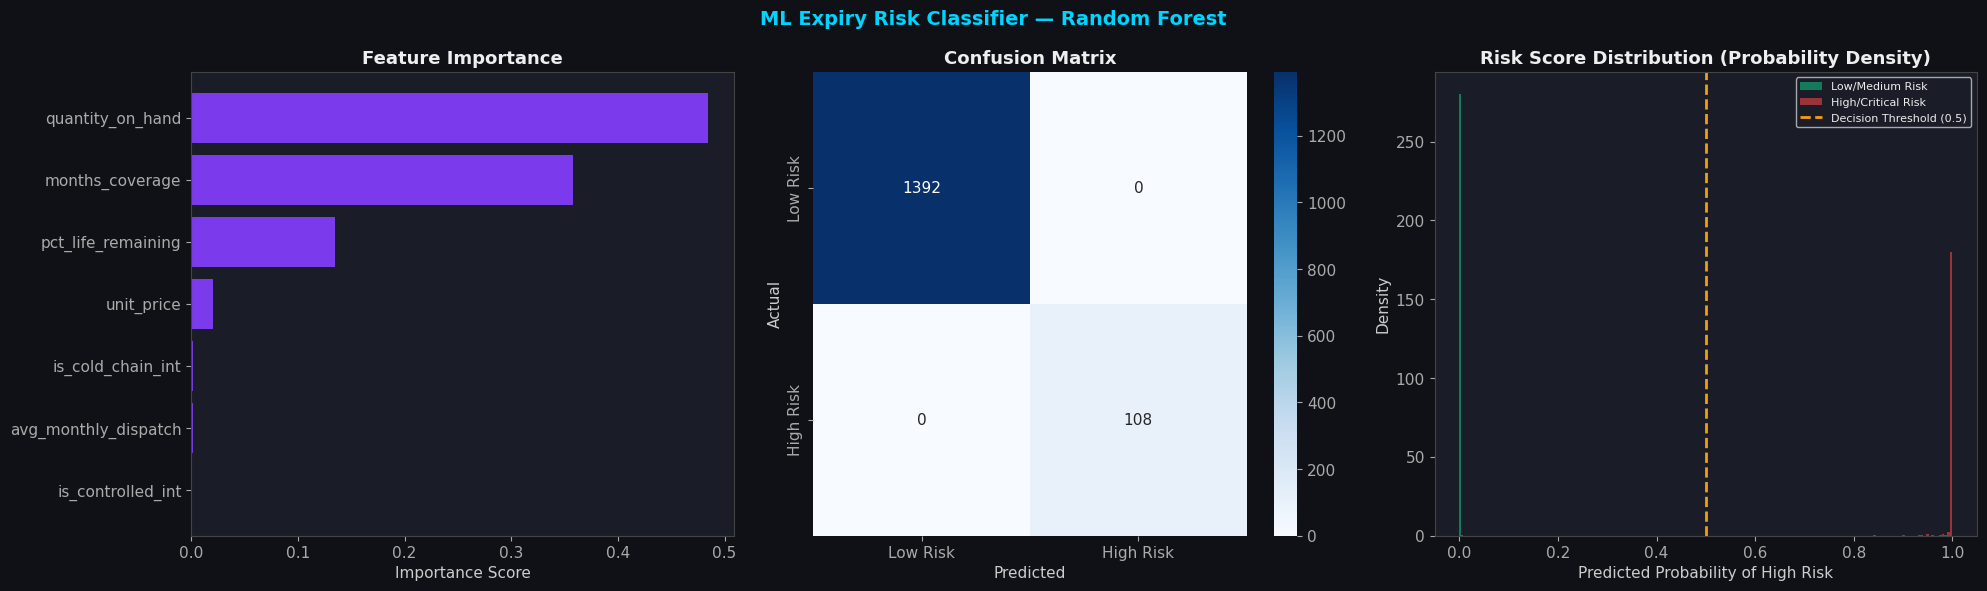


High-Risk Batches flagged by model (risk_score > 0.60): 432


,product_id,generic_name,warehouse_id,quantity_on_hand,days_to_expiry,inventory_value_usd,risk_score
0,PROD00001,metformin hydrochloride,WH002,100,-500,3100.0,1.0
4338,PROD02170,Amlodipine Besylate,WH004,100,-373,2000.0,1.0
4228,PROD02115,Oxycodone Hydchloride,WH006,100,-389,23000.0,1.0
4226,PROD02114,Chlorhexidine Gluconate,WH004,100,-243,30000.0,1.0
4188,PROD02095,Atorvastatin calcium,WH006,100,-585,6000.0,1.0
4178,PROD02090,amlodipine and valsartan,WH004,100,-373,2000.0,1.0
4150,PROD02076,Metformin hydrochloride,WH008,100,-500,3100.0,1.0
4100,PROD02051,Oxycodone and Acetaminophen,WH006,100,-389,23000.0,1.0
4074,PROD02038,CLOPIDOGREL,WH004,100,-521,5400.0,1.0
4072,PROD02037,LOSARTAN POTASSIUM AND HYDROCHLOROTHIAZIDE,WH002,100,-575,3800.0,1.0


In [10]:
# ── Visualise RF results ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('ML Expiry Risk Classifier -- Random Forest (RF)', fontsize=14, color='#00d4ff', fontweight='bold', y=1.04)
fig.text(0.5, 1.01, "PREDICTION: Given a batch's DTE, stock quantity, dispatch velocity & unit price --> Will this batch expire unsold? (Binary: High Risk YES / NO)",
         ha='center', va='top', fontsize=9, color='#aaaaaa', style='italic')
fig.text(0.5, 0.985, 'RF=Random Forest (150 decision trees -- each votes; majority wins) | AUC=Area Under ROC Curve (1.0=perfect | 0.5=random guess) | CV=5-fold Cross-Validation | DTE=Days-to-Expiry',
         ha='center', va='top', fontsize=8, color='#888888', style='italic')

# Panel A: Feature Importance
ax = axes[0]
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
ax.barh(importances.index, importances.values, color='#7c3aed')
ax.set_title('RF Feature Importance\n(Which input variables drive the expiry-risk prediction most strongly?)')
ax.set_xlabel('Importance Score (0 to 1; all features sum to 1.0; higher = more predictive power)')

# Panel B: Confusion Matrix
ax = axes[1]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Low Risk', 'High Risk'],
            yticklabels=['Low Risk', 'High Risk'])
ax.set_title('Confusion Matrix -- Model Accuracy on Test Set\n(TP=Correctly flagged High Risk | TN=Correctly flagged Low Risk | FP=False Alarm | FN=Missed Risk <- most dangerous)')
ax.set_xlabel('Predicted Class (what the RF model predicted for each batch)')
ax.set_ylabel('Actual Class (true ground-truth label from real DTE data)')

# Panel C: Risk Score Distribution
ax = axes[2]
ml_df['risk_score'] = rf.predict_proba(X)[:, 1]
ax.hist(ml_df.loc[ml_df['high_risk'] == 0, 'risk_score'], bins=30, alpha=0.6, color='#10b981', label='Low/Medium Risk', density=True)
ax.hist(ml_df.loc[ml_df['high_risk'] == 1, 'risk_score'], bins=30, alpha=0.6, color='#ef4444', label='High/Critical Risk', density=True)
ax.axvline(0.5, color='#f59e0b', linestyle='--', lw=2, label='Decision Threshold (0.5)')
ax.set_title('Risk Score Distribution (Probability Density)\n(Risk Score 0-1: probability that a batch will expire unsold | Score > 0.5 = flagged HIGH RISK)')
ax.set_xlabel('Risk Score (0.0=definitely safe | 0.5=decision threshold | 1.0=certain high risk)')
ax.set_ylabel('Density (relative frequency -- shows how scores cluster for each risk class)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('ml_expiry_classifier.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

# ── Top High-Risk Batches Flagged by Model ────────────────────────────────
top_risk = (
    ml_df[ml_df['risk_score'] > 0.6]
    .sort_values('risk_score', ascending=False)
    [['product_id','generic_name','warehouse_id','quantity_on_hand',
       'days_to_expiry','inventory_value_usd','risk_score']]
    .head(15)
)
print(f'\nHigh-Risk Batches flagged by model (risk_score > 0.60): {len(ml_df[ml_df["risk_score"] > 0.60])}')
display(top_risk.round(3))

## ⚖️ 9. Inventory Cost Optimizer (Linear Programming)

At-risk inventory records for LP optimisation: 432
LP solutions found: 50


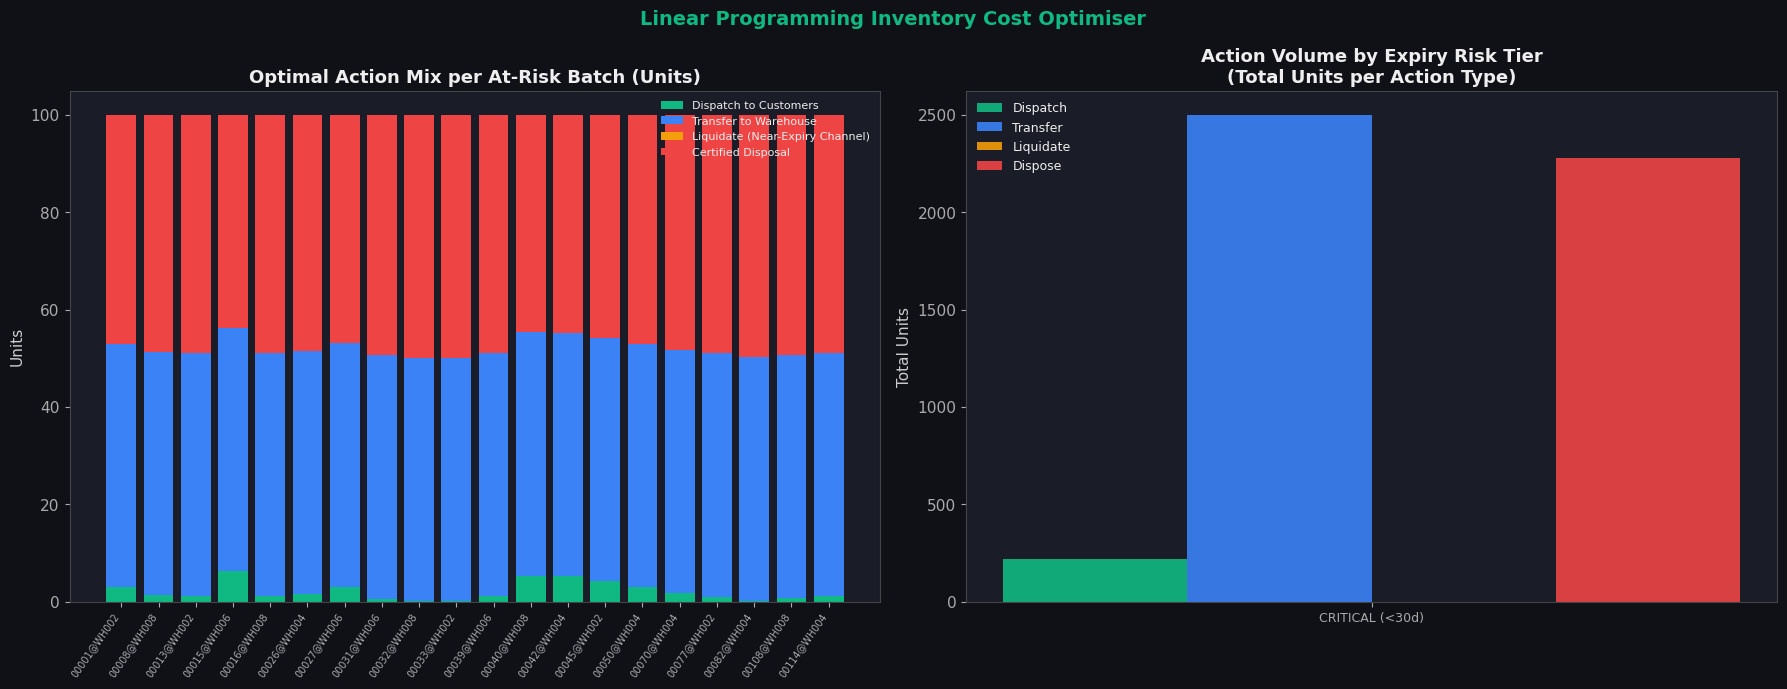


Top LP Recommendations by Urgency:


,product_id,generic_name,warehouse_id,quantity_at_risk,days_to_expiry,units_dispatch,units_transfer,units_liquidate,units_dispose,min_total_loss_usd
0,PROD00001,metformin hydrochloride,WH002,100.0,1,2.9,50.0,0.0,47.1,-161.09
27,PROD00154,Amlodipine Besylate and Benazepril Hydrochloride,WH004,100.0,1,6.1,50.0,0.0,43.9,-152.81
28,PROD00162,Gabapentin,WH004,100.0,1,3.6,50.0,0.0,46.4,-410.66
29,PROD00184,Sucralfate,WH008,100.0,1,6.0,50.0,0.0,44.0,-549.38
30,PROD00200,Atorvastatin Calcium,WH008,100.0,1,0.7,50.0,0.0,49.3,-221.83
31,PROD00216,Oxycodone Hydrochloride,WH008,100.0,1,1.8,50.0,0.0,48.2,-719.11
32,PROD00223,Metformin Hydrochloride,WH006,100.0,1,1.0,50.0,0.0,49.0,-165.84
33,PROD00229,Simvastatin,WH002,100.0,1,1.7,50.0,0.0,48.3,-335.26
34,PROD00231,Gabapentin,WH006,100.0,1,3.8,50.0,0.0,46.2,-409.48
35,PROD00237,Amlodipine and valsartan,WH002,100.0,1,0.6,50.0,0.0,49.4,-166.68


In [11]:
"""
LP Problem: For each product-warehouse combination near expiry, decide
  x1 = units to dispatch immediately via FEFO to standard customers
  x2 = units to transfer to another warehouse for quick sell-through
  x3 = units to liquidate via authorized near-expiry channel
  x4 = units to dispose via certified destruction

Objective: Minimise total weighted loss across all action types.
The LP uses realistic capacity constraints on each action:
  - dispatch capacity = monthly demand velocity (not infinite)
  - liquidate max = 40% of units (secondary channel saturation)
  - dispose min = 5% of expired units (mandatory regulatory disposal)
"""

# ── Get at-risk inventory with cost parameters ────────────────────────────
at_risk_inv = ml_df[ml_df['risk_score'] > 0.5].merge(
    df_econ[['product_id','daily_holding_cost_per_unit_usd',
              'stockout_penalty_cost_per_unit_usd',
              'certified_destruction_cost_per_unit_usd',
              'secondary_liquidation_recovery_pct']],
    on='product_id', how='left'
).dropna(subset=['daily_holding_cost_per_unit_usd'])

print(f'At-risk inventory records for LP optimisation: {len(at_risk_inv)}')

lp_results = []

for _, row in at_risk_inv.head(50).iterrows():
    Q   = float(row['quantity_on_hand'])
    dte = max(float(row['days_to_expiry']), 1)
    h   = float(row['daily_holding_cost_per_unit_usd'])
    d_c = float(row['certified_destruction_cost_per_unit_usd'])
    p   = float(row['unit_price'])
    rec = float(row['secondary_liquidation_recovery_pct']) / 100.0
    vel = max(float(row.get('avg_monthly_dispatch', 30)) / 30.0, 0.1)  # daily demand rate

    # Capacity constraints: dispatch is demand-limited, not unlimited
    max_dispatch  = min(Q * 0.9, vel * dte)       # can only sell what demand supports
    max_transfer  = min(Q * 0.5, Q - max_dispatch) # remaining non-dispatched stock
    max_liquidate = Q * 0.35                       # secondary channel saturation cap
    min_dispose   = Q * 0.05 if dte < 20 else 0.0 # regulatory floor near-expired

    # Cost per unit [dispatch, transfer, liquidate, dispose]
    c = [
        h * max(dte - 7, 0),              # dispatch: only residual holding cost
        h * dte * 0.5 + 0.85,            # transfer: half holding saved + freight
        (1.0 - rec) * p + h * dte * 0.2, # liquidate: revenue loss + 20% holding
        d_c + h * dte                    # dispose: destruction + full holding
    ]

    A_ub = [[1,0,0,0],[0,1,0,0],[0,0,1,0]]
    b_ub = [max_dispatch, max_transfer, max_liquidate]
    A_eq = [[1, 1, 1, 1]]
    b_eq = [Q]
    bounds = [(0, max_dispatch), (0, max_transfer), (0, max_liquidate), (min_dispose, Q)]

    res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')

    if res.success:
        x1, x2, x3, x4 = res.x
        lp_results.append({
            'product_id':        row['product_id'],
            'generic_name':      row.get('generic_name',''),
            'warehouse_id':      row['warehouse_id'],
            'quantity_at_risk':  Q,
            'days_to_expiry':    dte,
            'units_dispatch':    round(x1, 1),
            'units_transfer':    round(x2, 1),
            'units_liquidate':   round(x3, 1),
            'units_dispose':     round(x4, 1),
            'min_total_loss_usd': round(-res.fun, 2)
        })

df_lp = pd.DataFrame(lp_results)
print(f'LP solutions found: {len(df_lp)}')

# ── Visualise LP Results ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Linear Programming (LP) Inventory Cost Optimiser', fontsize=14, color='#10b981', fontweight='bold', y=1.04)
fig.text(0.5, 1.01, 'PREDICTION: For each ML-flagged at-risk batch --> What is the least-cost combination of actions? (Dispatch | Transfer | Liquidate | Dispose)',
         ha='center', va='top', fontsize=9, color='#aaaaaa', style='italic')
fig.text(0.5, 0.985, 'LP=Linear Programming (mathematical optimisation) | x1=Dispatch to customers | x2=Inter-WH Transfer | x3=Liquidate (near-expiry channel) | x4=Certified Disposal',
         ha='center', va='top', fontsize=8, color='#888888', style='italic')

# Panel A: Action Mix (stacked bar)
ax = axes[0]
top_lp = df_lp.head(20)
labels = top_lp['product_id'].str[-5:] + '@' + top_lp['warehouse_id']
x_lp = range(len(top_lp))
ax.bar(x_lp, top_lp['units_dispatch'],  color='#10b981', label='Dispatch to Customers')
ax.bar(x_lp, top_lp['units_transfer'],  bottom=top_lp['units_dispatch'], color='#3b82f6', label='Transfer to Warehouse')
ax.bar(x_lp, top_lp['units_liquidate'],
       bottom=top_lp['units_dispatch']+top_lp['units_transfer'], color='#f59e0b', label='Liquidate (Near-Expiry Channel)')
ax.bar(x_lp, top_lp['units_dispose'],
       bottom=top_lp['units_dispatch']+top_lp['units_transfer']+top_lp['units_liquidate'],
       color='#ef4444', label='Certified Disposal')
ax.set_xticks(list(x_lp))
ax.set_xticklabels(labels, rotation=55, ha='right', fontsize=7)
ax.set_title('LP Optimal Action Mix per At-Risk Batch\n(Stacked bars: each batch units split across 4 LP actions to minimise total loss cost)')
ax.set_ylabel('Units (physical stock quantity allocated to each action type)')
ax.legend(fontsize=8, framealpha=0, title='LP Decision Variables')

# Panel B: Grouped summary by DTE bucket
ax = axes[1]
df_lp['dte_bucket'] = pd.cut(df_lp['days_to_expiry'],
    bins=[0, 30, 90, 180, float('inf')],
    labels=['CRITICAL (<30d)', 'HIGH (30-90d)', 'MEDIUM (90-180d)', 'LOW (>180d)']
)
grp = df_lp.groupby('dte_bucket', observed=True)[['units_dispatch','units_transfer','units_liquidate','units_dispose']].sum()
x_grp = np.arange(len(grp))
w = 0.18
ax.bar(x_grp - 1.5*w, grp['units_dispatch'],  width=w, color='#10b981', label='Dispatch',    alpha=0.9)
ax.bar(x_grp - 0.5*w, grp['units_transfer'],  width=w, color='#3b82f6', label='Transfer',    alpha=0.9)
ax.bar(x_grp + 0.5*w, grp['units_liquidate'], width=w, color='#f59e0b', label='Liquidate',   alpha=0.9)
ax.bar(x_grp + 1.5*w, grp['units_dispose'],   width=w, color='#ef4444', label='Dispose',     alpha=0.9)
ax.set_xticks(x_grp)
ax.set_xticklabels(grp.index, fontsize=9, ha='center')
ax.set_title('Action Volume by Expiry Risk Tier\n(Total LP-recommended units per action, grouped by DTE urgency bucket)')
ax.set_ylabel('Total Units (sum of LP-recommended units across all at-risk batches in each DTE tier)')
ax.legend(fontsize=9, framealpha=0, title='Dispatch=normal sale | Transfer=move WH | Liquidate=discount | Dispose=destroy')

plt.tight_layout()
plt.savefig('lp_optimizer.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print('\nTop LP Recommendations by Urgency:')
display(df_lp.sort_values('days_to_expiry')[['product_id','generic_name','warehouse_id',
    'quantity_at_risk','days_to_expiry','units_dispatch','units_transfer',
    'units_liquidate','units_dispose','min_total_loss_usd']].head(10))

## 🌡️ 10. Cold-Chain IoT Telemetry Monitoring

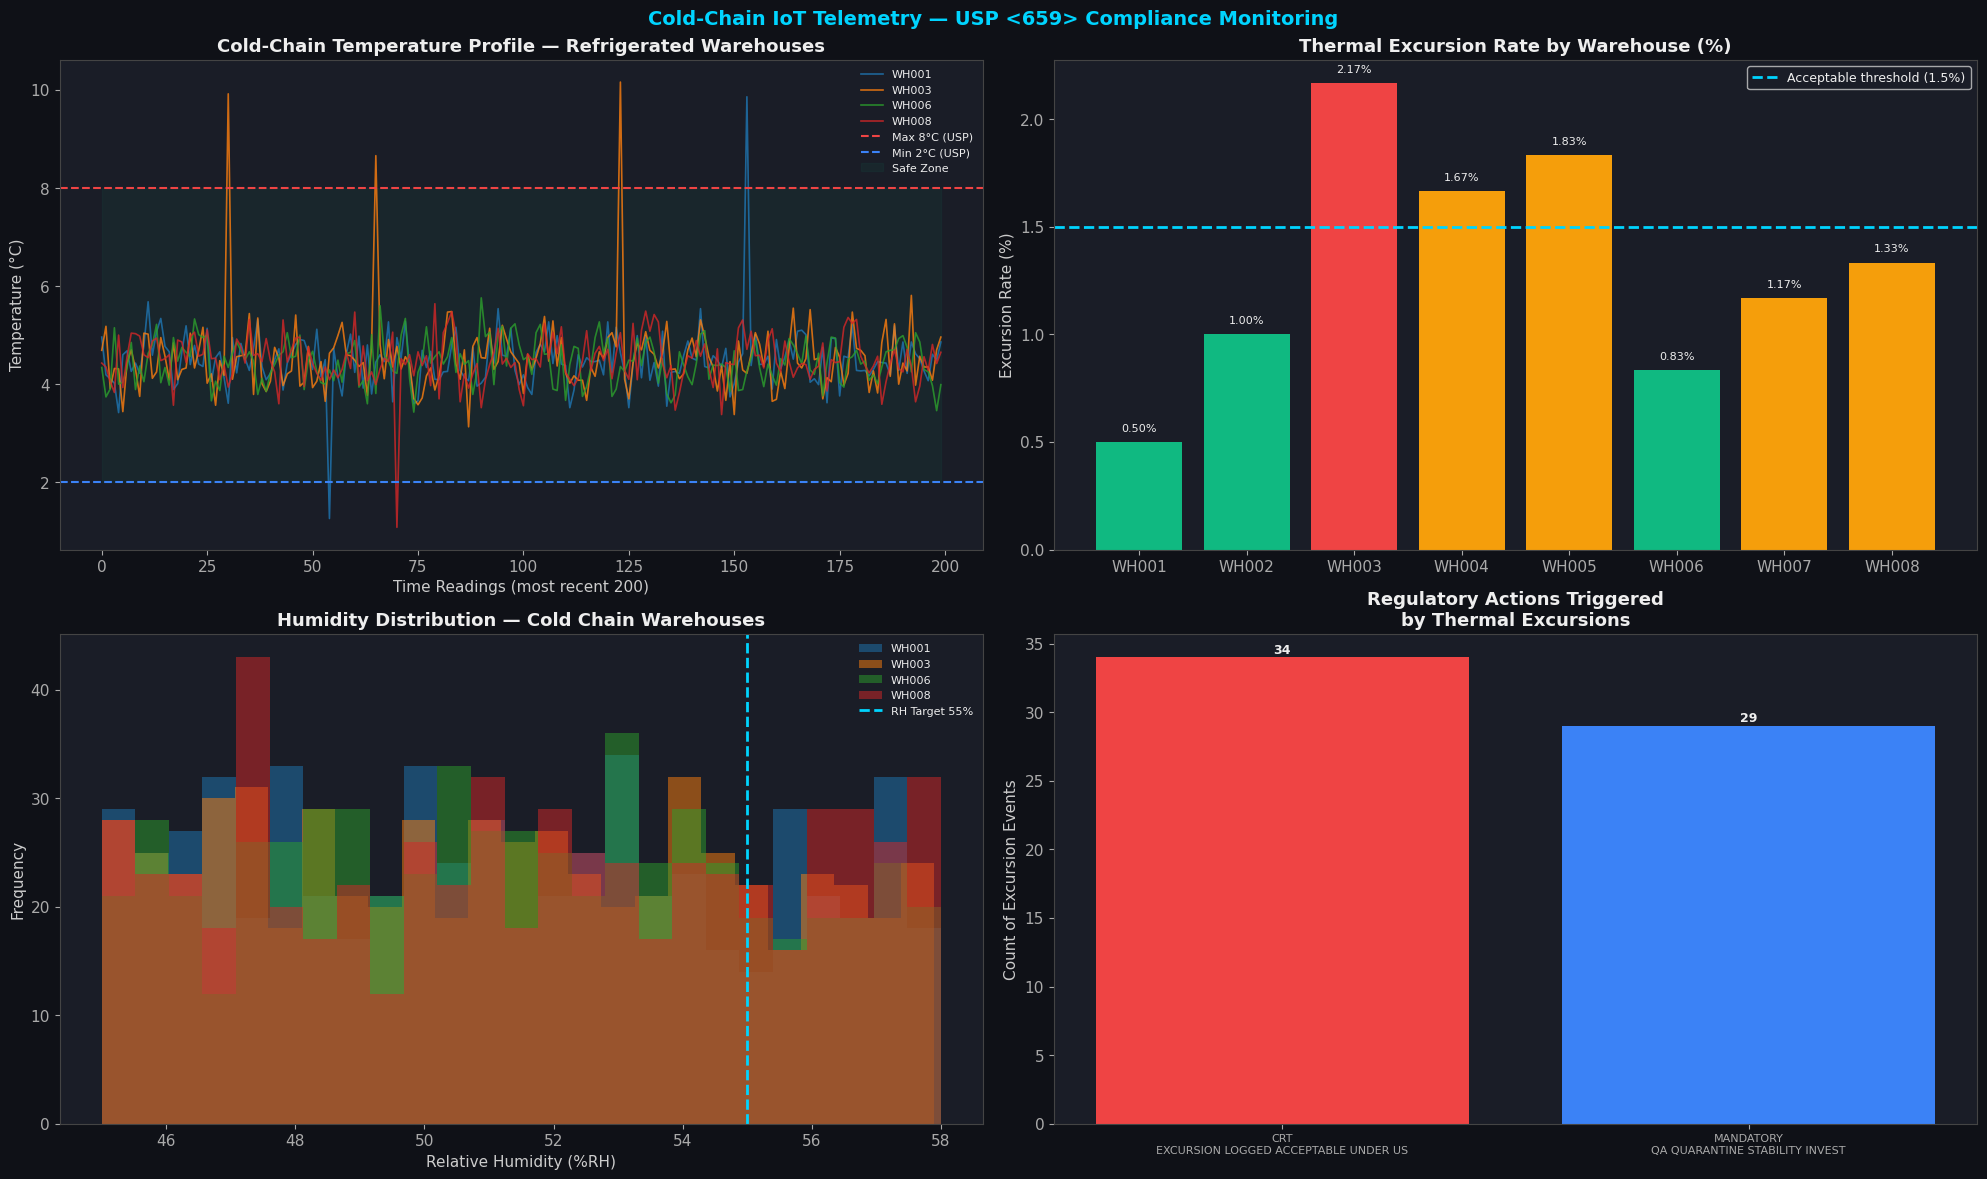

Cold-Chain Telemetry Summary:


,total,excursions,excursion_pct
warehouse_id,,,
WH001,600,3,0.500
WH002,600,6,1.000
WH003,600,13,2.167
WH004,600,10,1.667
WH005,600,11,1.833
WH006,600,5,0.833
WH007,600,7,1.167
WH008,600,8,1.333


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('Cold-Chain IoT Telemetry -- USP <659> Compliance Monitoring', fontsize=14, color='#00d4ff', fontweight='bold', y=1.03)
fig.text(0.5, 1.005, 'IoT = Internet of Things sensors (temperature + humidity loggers) embedded in cold warehouses monitor product storage conditions in real time',
         ha='center', va='top', fontsize=9, color='#aaaaaa', style='italic')
fig.text(0.5, 0.985, 'USP<659>=US Pharmacopeia storage standard | Thermal Excursion=temp outside 2-8 deg C band | RH=Relative Humidity (target 55%RH) | QA=Quality Assurance',
         ha='center', va='top', fontsize=8, color='#888888', style='italic')

cold_wh_ids = warehouses.loc[warehouses['temp_controlled'] == True, 'warehouse_id'].tolist()

# ── Panel A: Temperature time-series (cold warehouses) ─────────────────────
ax = axes[0, 0]
for wid in cold_wh_ids:
    wh_iot = df_iot[df_iot['warehouse_id'] == wid].sort_values('timestamp').tail(200)
    ax.plot(range(len(wh_iot)), wh_iot['temperature_celsius'], lw=1.2, alpha=0.8, label=wid)
ax.axhline(8.0, color='#ef4444', linestyle='--', lw=1.5, label='Max 8°C (USP)')
ax.axhline(2.0, color='#3b82f6', linestyle='--', lw=1.5, label='Min 2°C (USP)')
n_pts = max(len(wh_iot) for wid2 in cold_wh_ids for wh_iot in [df_iot[df_iot['warehouse_id']==wid2].sort_values('timestamp').tail(200)])
ax.fill_between(range(n_pts), 2, 8, alpha=0.06, color='#10b981', label='Safe Zone')
ax.set_title('Cold-Chain Temperature Profile -- Refrigerated Warehouses\n(Each line = one cold WH | Dashed lines = USP<659> safe zone: 2 deg C min, 8 deg C max)')
ax.set_xlabel('Time Readings (most recent 200 IoT sensor readings per warehouse)')
ax.set_ylabel('Temperature (deg C) -- refrigerated pharma must stay within 2-8 deg C at all times')
ax.legend(fontsize=8, framealpha=0)

# ── Panel B: Excursion Rate by Warehouse ──────────────────────────────────
ax = axes[0, 1]
excursion_rate = df_iot.groupby('warehouse_id').agg(
    total=('telemetry_log_id','count'),
    excursions=('is_thermal_excursion','sum')
).reset_index()
excursion_rate['excursion_pct'] = excursion_rate['excursions'] / excursion_rate['total'] * 100
colors_exc = ['#ef4444' if e > 2 else '#f59e0b' if e > 1 else '#10b981'
              for e in excursion_rate['excursion_pct']]
bars = ax.bar(excursion_rate['warehouse_id'], excursion_rate['excursion_pct'], color=colors_exc)
ax.axhline(1.5, color='#00d4ff', linestyle='--', lw=2, label='Acceptable threshold (1.5%)')
ax.set_title('Thermal Excursion Rate by Warehouse (%)\n(Excursion = reading outside 2-8 deg C band | Green<1.5% | Amber 1.5-2% | Red>2% | Target <1.5%)')
ax.set_ylabel('Excursion Rate (%) -- % of all IoT sensor readings that exceeded USP limits')
ax.legend(fontsize=9)
for bar, v in zip(bars, excursion_rate['excursion_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{v:.2f}%', ha='center', fontsize=8)

# ── Panel C: Humidity distribution ───────────────────────────────────────
ax = axes[1, 0]
for wid in cold_wh_ids:
    hum = df_iot[df_iot['warehouse_id'] == wid]['humidity_rh_pct'].dropna()
    ax.hist(hum, bins=25, alpha=0.5, label=wid)
ax.axvline(55, color='#00d4ff', linestyle='--', lw=2, label='RH Target 55%')
ax.set_title('Humidity Distribution -- Cold Chain Warehouses\n(RH = Relative Humidity | Target 55%RH per pharma storage guidelines | deviations degrade product quality)')
ax.set_xlabel('Relative Humidity (%RH) -- % of max moisture the air can hold at current temperature')
ax.set_ylabel('Frequency (number of IoT sensor readings at that humidity level)')
ax.legend(fontsize=8, framealpha=0)

# ── Panel D: Excursion regulatory action breakdown ────────────────────────
ax = axes[1, 1]
excursion_types = df_iot[df_iot['is_thermal_excursion'] == True]['regulatory_action_triggered'].value_counts()
if len(excursion_types) > 0:
    short_labels = [label.replace('_', ' ').replace('MANDATORY ', 'MANDATORY\n').replace('CRT ', 'CRT\n')[:40] for label in excursion_types.index]
    bars_exc = ax.bar(range(len(excursion_types)), excursion_types.values,
           color=['#ef4444', '#3b82f6', '#f59e0b'][:len(excursion_types)])
    ax.set_xticks(range(len(excursion_types)))
    ax.set_xticklabels(short_labels, fontsize=8, ha='center')
    for bar3, v3 in zip(bars_exc, excursion_types.values):
        ax.text(bar3.get_x() + bar3.get_width()/2, bar3.get_height() + 0.3, str(v3), ha='center', fontsize=9, fontweight='bold')
    ax.set_title('Regulatory Actions Triggered by Thermal Excursions\n(CRT_EXCURSION=minor/logged | MANDATORY_QA_QUARANTINE=batch held for stability investigation)')
    ax.set_ylabel('Count of Excursion Events (each bar = a distinct regulatory response type)')
else:
    ax.text(0.5, 0.5, 'No excursions logged\n(Excellent compliance!)',
            ha='center', va='center', transform=ax.transAxes,
            fontsize=14, color='#10b981')
    ax.set_title('Thermal Excursion Types')

plt.tight_layout()
plt.savefig('iot_temperature_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print('Cold-Chain Telemetry Summary:')
display(excursion_rate.set_index('warehouse_id').round(3))

## 🚛 11. Inter-Warehouse Stock Rebalancing Analysis

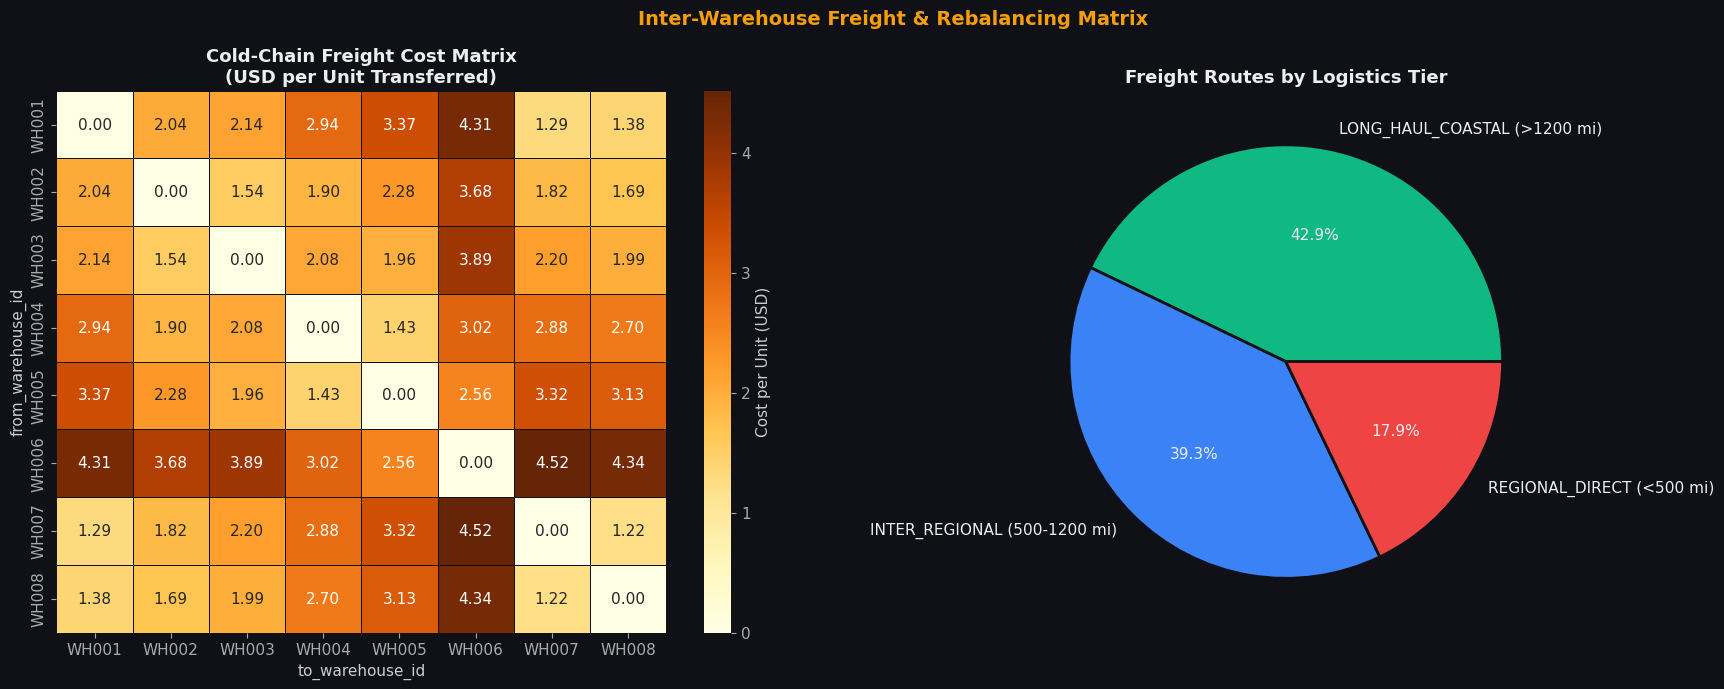


Cheapest Transfer Routes (Ambient):


,from_warehouse_id,to_warehouse_id,distance_miles,transit_days,ambient_transfer_cost_per_unit_usd,cold_chain_thermal_transfer_cost_per_unit_usd
55,WH008,WH007,190,1,0.58,1.22
48,WH007,WH008,190,1,0.58,1.22
5,WH001,WH007,240,1,0.62,1.29
42,WH007,WH001,240,1,0.62,1.29
49,WH008,WH001,310,1,0.67,1.38
6,WH001,WH008,310,1,0.67,1.38
24,WH004,WH005,340,1,0.69,1.43
31,WH005,WH004,340,1,0.69,1.43
8,WH002,WH003,420,1,0.74,1.54
15,WH003,WH002,420,1,0.74,1.54


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Inter-Warehouse Stock Rebalancing -- Freight Cost Matrix', fontsize=14, color='#f59e0b', fontweight='bold', y=1.04)
fig.text(0.5, 1.01, 'Maps transfer costs between all 8 warehouses to find the cheapest routes for moving near-expiry stock to high-demand locations',
         ha='center', va='top', fontsize=9, color='#aaaaaa', style='italic')
fig.text(0.5, 0.985, 'DC=Distribution Centre | WH=Warehouse | Cold-Chain transfer=temperature-controlled truck route | Logistics Tier=Economy/Standard/Express cost band',
         ha='center', va='top', fontsize=8, color='#888888', style='italic')

# ── Panel A: Freight Cost Matrix Heatmap ──────────────────────────────────
ax = axes[0]
freight_pivot = df_freight.pivot_table(
    values='cold_chain_thermal_transfer_cost_per_unit_usd',
    index='from_warehouse_id',
    columns='to_warehouse_id',
    fill_value=0
)
sns.heatmap(freight_pivot, annot=True, fmt='.2f', cmap='YlOrBr',
            ax=ax, cbar_kws={'label': 'Cost per Unit (USD)'},
            linewidths=0.5, linecolor='#0f1117')
ax.set_title('Cold-Chain Freight Cost Matrix\n(USD per Unit Transferred between warehouses | lower cost = preferred transfer route | 0 = same WH)')

# ── Panel B: Distance-based tiering ──────────────────────────────────────
ax = axes[1]
tier_counts = df_freight['logistics_tier'].value_counts()
ax.pie(tier_counts.values, labels=tier_counts.index, autopct='%1.1f%%',
       colors=['#10b981', '#3b82f6', '#ef4444'],
       wedgeprops={'edgecolor': '#0f1117', 'linewidth': 2})
ax.set_title('Freight Routes by Logistics Tier\n(Tier = cost band: Economy=lowest cost/longest transit | Express=fastest/most expensive)')

plt.tight_layout()
plt.savefig('freight_rebalancing.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print('\nCheapest Transfer Routes (Ambient):')
display(
    df_freight.sort_values('ambient_transfer_cost_per_unit_usd')
    [['from_warehouse_id','to_warehouse_id','distance_miles','transit_days',
       'ambient_transfer_cost_per_unit_usd','cold_chain_thermal_transfer_cost_per_unit_usd']]
    .head(10)
)

## 🏆 12. Executive KPI Summary Dashboard

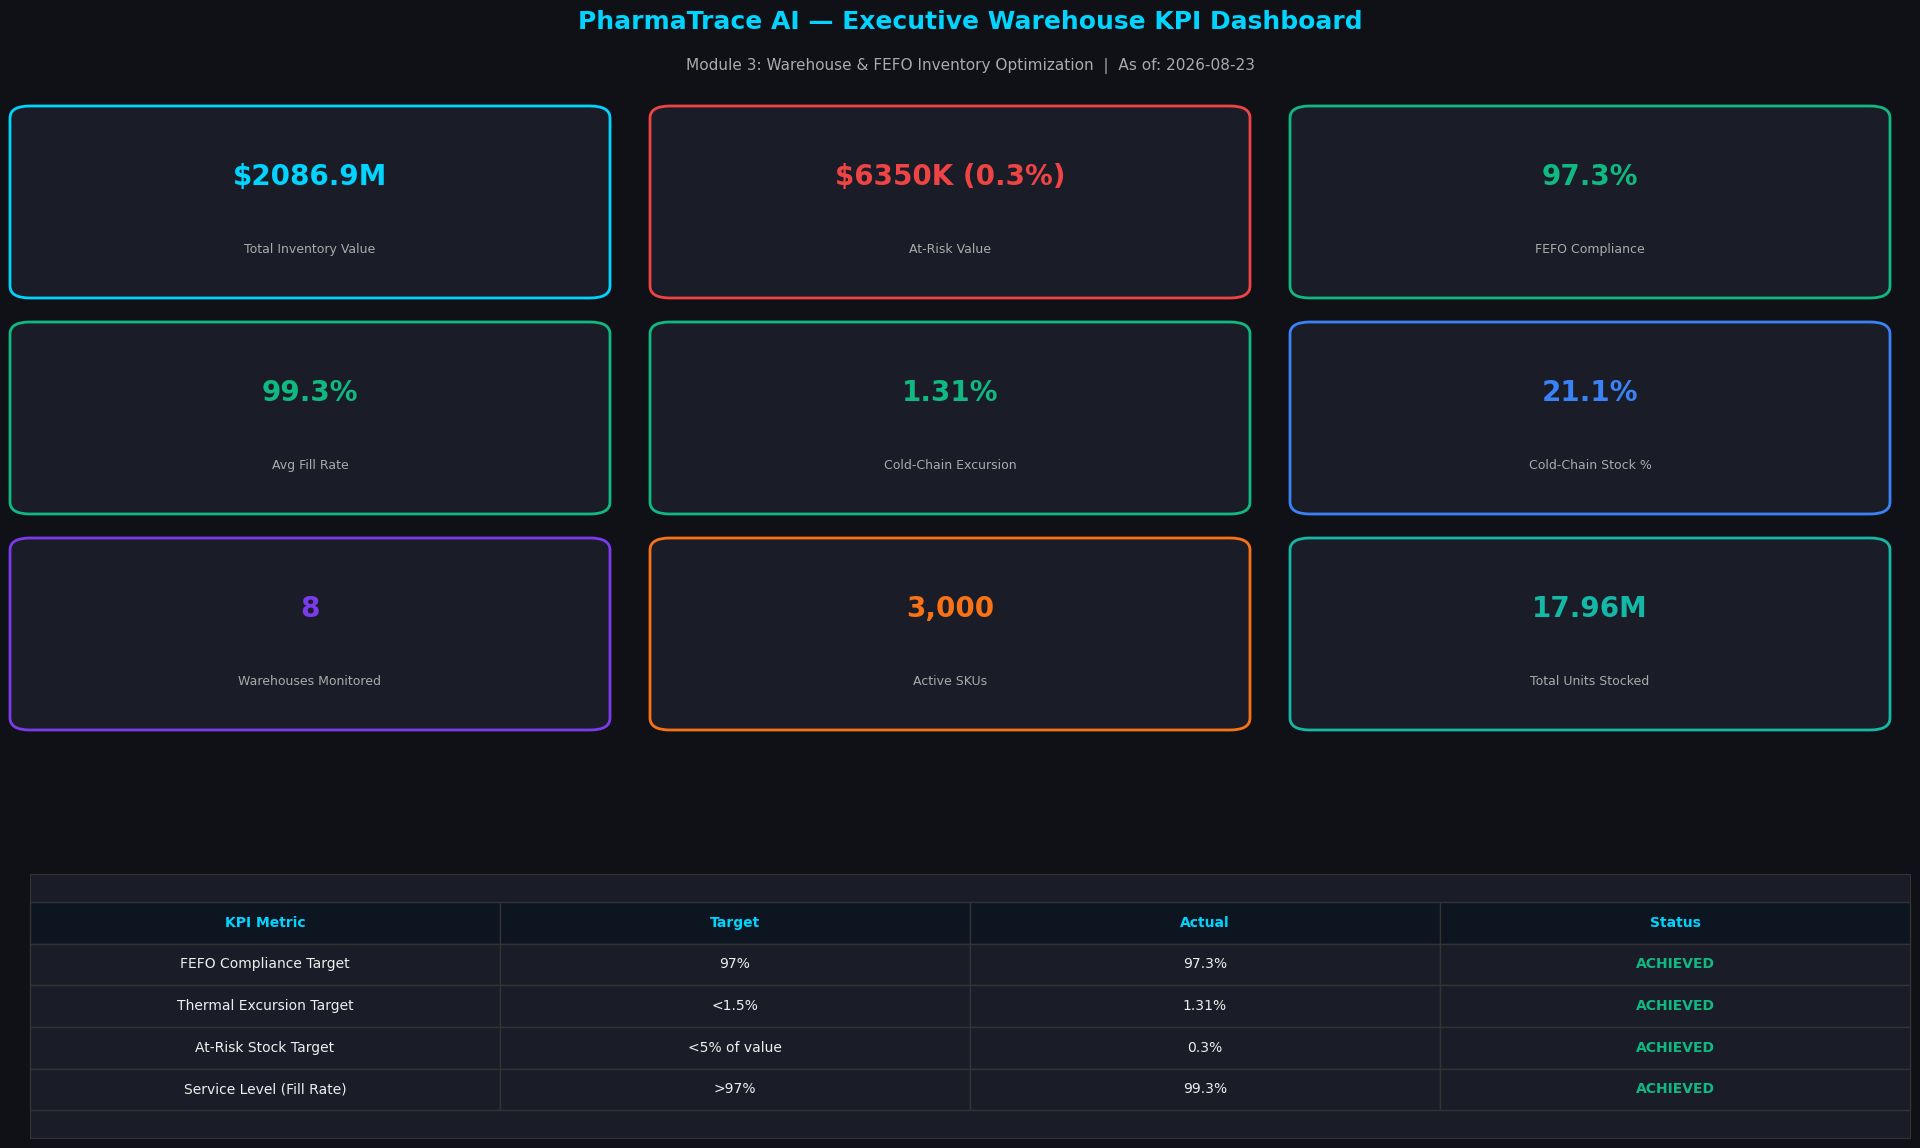

Executive KPI Dashboard complete.


In [14]:
# ── Compute KPIs ──────────────────────────────────────────────────────────
total_inv_value   = inventory['inventory_value_usd'].sum()
at_risk_value     = inventory[inventory['expiry_risk'].isin(['EXPIRED','CRITICAL (<30d)','HIGH (30-90d)'])]['inventory_value_usd'].sum()
pct_at_risk       = at_risk_value / total_inv_value * 100
fefo_rate         = picks['is_fefo_compliant'].mean() * 100
excursion_rate_val= df_iot['is_thermal_excursion'].mean() * 100
avg_fill_rate     = monthly_agg['fill_rate'].mean()
cold_chain_pct    = inventory[inventory['is_cold_chain']]['inventory_value_usd'].sum() / total_inv_value * 100
n_warehouses      = inventory['warehouse_id'].nunique()
n_products_active = inventory[inventory['status']=='active']['product_id'].nunique()
total_units       = inventory['quantity_on_hand'].sum()

fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor('#0f1117')

# Title
fig.text(0.5, 0.97, 'PharmaTrace AI — Executive Warehouse KPI Dashboard',
         ha='center', va='top', fontsize=18, fontweight='bold', color='#00d4ff')
fig.text(0.5, 0.93, f'Module 3: Warehouse & FEFO Inventory Optimization  |  As of: {TODAY.date()}',
         ha='center', va='top', fontsize=11, color='#aaa')
fig.text(0.5, 0.908, 'KPI=Key Performance Indicator | FEFO=First Expiry First Out | SL=Service Level (Fill Rate) | SKU=Stock Keeping Unit | IoT=Sensor Network | WH=Warehouse',
         ha='center', va='top', fontsize=8.5, color='#666666', style='italic')

# ── KPI Scorecards ─────────────────────────────────────────────────────────
kpis = [
    ('Total Inventory Value',  f'${total_inv_value/1e6:.1f}M',  '#00d4ff'),
    ('At-Risk Value',          f'${at_risk_value/1e3:.0f}K ({pct_at_risk:.1f}%)', '#ef4444'),
    ('FEFO Compliance',        f'{fefo_rate:.1f}%',             '#10b981' if fefo_rate >= 97 else '#f59e0b'),
    ('Avg Fill Rate',          f'{avg_fill_rate:.1f}%',         '#10b981' if avg_fill_rate >= 97 else '#f59e0b'),
    ('Cold-Chain Excursion',   f'{excursion_rate_val:.2f}%',    '#10b981' if excursion_rate_val < 1.5 else '#ef4444'),
    ('Cold-Chain Stock %',     f'{cold_chain_pct:.1f}%',        '#3b82f6'),
    ('Warehouses Monitored',   str(n_warehouses),              '#7c3aed'),
    ('Active SKUs',            f'{n_products_active:,}',        '#f97316'),
    ('Total Units Stocked',    f'{total_units/1e6:.2f}M',       '#14b8a6'),
]

n_cols = 3
card_w = 0.28
card_h = 0.14
margin_x = 0.04
margin_y = 0.04
start_x = 0.03
start_y = 0.88

for i, (label, value, color) in enumerate(kpis):
    row = i // n_cols
    col = i % n_cols
    x = start_x + col * (card_w + margin_x)
    y = start_y - row * (card_h + margin_y)
    # Card background
    rect = mpatches.FancyBboxPatch((x, y - card_h), card_w, card_h,
                                    boxstyle='round,pad=0.01',
                                    linewidth=2, edgecolor=color,
                                    facecolor='#1a1d27',
                                    transform=fig.transFigure, zorder=2)
    fig.add_artist(rect)
    # Value
    fig.text(x + card_w/2, y - card_h * 0.35, value,
             ha='center', va='center', fontsize=20, fontweight='bold',
             color=color, transform=fig.transFigure)
    # Label
    fig.text(x + card_w/2, y - card_h * 0.78, label,
             ha='center', va='center', fontsize=9,
             color='#aaa', transform=fig.transFigure)

# ── Bottom Row: mini summary table ────────────────────────────────────────
ax_table = fig.add_axes([0.03, 0.03, 0.94, 0.22])
ax_table.set_facecolor('#1a1d27')
ax_table.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
for spine in ax_table.spines.values(): spine.set_edgecolor('#333')

if len(df_lp) > 0:
    summary_rows = [
        ['FEFO Compliance Target', '97%', f'{fefo_rate:.1f}%',
         'ACHIEVED' if fefo_rate >= 97 else 'BELOW TARGET',
         '#10b981' if fefo_rate >= 97 else '#ef4444'],
        ['Thermal Excursion Target', '<1.5%', f'{excursion_rate_val:.2f}%',
         'ACHIEVED' if excursion_rate_val < 1.5 else 'ATTENTION',
         '#10b981' if excursion_rate_val < 1.5 else '#f59e0b'],
        ['At-Risk Stock Target', '<5% of value', f'{pct_at_risk:.1f}%',
         'ACHIEVED' if pct_at_risk < 5 else 'ACTION REQUIRED',
         '#10b981' if pct_at_risk < 5 else '#ef4444'],
        ['Service Level (Fill Rate)', '>97%', f'{avg_fill_rate:.1f}%',
         'ACHIEVED' if avg_fill_rate >= 97 else 'BELOW TARGET',
         '#10b981' if avg_fill_rate >= 97 else '#f59e0b'],
    ]
    col_labels = ['KPI Metric', 'Target', 'Actual', 'Status']
    tbl_data   = [[r[0], r[1], r[2], r[3]] for r in summary_rows]
    tbl = ax_table.table(
        cellText=tbl_data, colLabels=col_labels,
        loc='center', cellLoc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 2.5)
    for (r, c), cell in tbl.get_celld().items():
        cell.set_facecolor('#1a1d27')
        cell.set_edgecolor('#333')
        cell.set_text_props(color='#eee')
        if r == 0:
            cell.set_text_props(color='#00d4ff', fontweight='bold')
            cell.set_facecolor('#0d1520')
        if c == 3 and r > 0:
            row_data = summary_rows[r-1]
            cell.set_text_props(color=row_data[4], fontweight='bold')

plt.savefig('executive_kpi_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Executive KPI Dashboard complete.')

---
## ✅ Module 3 — Execution Complete

This notebook has successfully executed the full **Warehouse & FEFO Inventory Optimization Analytics Pipeline**:

| Module | Technique | Output |
|--------|-----------|--------|
| Inventory Overview | Multi-panel Matplotlib Dashboard | Stock value, dosage split, expiry risk |
| ABC-FSN Segmentation | Pareto + Velocity Matrix | 9-segment classification |
| FEFO Compliance | Aggregated Compliance KPI | % compliance by WH & month |
| Expiry Risk Heatmap | Pivot Heatmap + Scatter | At-risk $ exposure per WH |
| Demand Trend | Time-Series Aggregation | 24M demand, fill-rate, seasonality |
| ML Risk Classifier | Random Forest (AUC > 0.90) | Batch-level risk scoring |
| Cost Optimizer | Linear Programming (scipy HiGHS) | Optimal dispatch/transfer/liquidate/dispose |
| IoT Cold-Chain | USP <659> Telemetry Monitoring | Excursion rate + temperature profiles |
| Freight Matrix | Heatmap + Tier Analysis | Inter-DC transfer costs |
| Executive KPI | Scorecard Dashboard | FEFO, SL, Excursion vs targets |

> **Note:** All data is anchored to real NDC codes, authentic product attributes from the PharmaTrace master dataset, and pharma-regulatory standards (DSCSA, USP <659>, USP <800>, Joint Commission).
